## Metaheuristic-Optimized Decision Tree Classification for Water Quality classification with SMOTE Balancing and GUI Deployment

Water is a fundamental resource for life yet only a small fraction of Earth's water is readily usable. The fast growth of the global population has had a tremendous impact on the environment, notably water quality. Water quality has deteriorated in recent years owing to a variety of contaminants. To reduce water pollution, modeling and predicting water quality has become critical


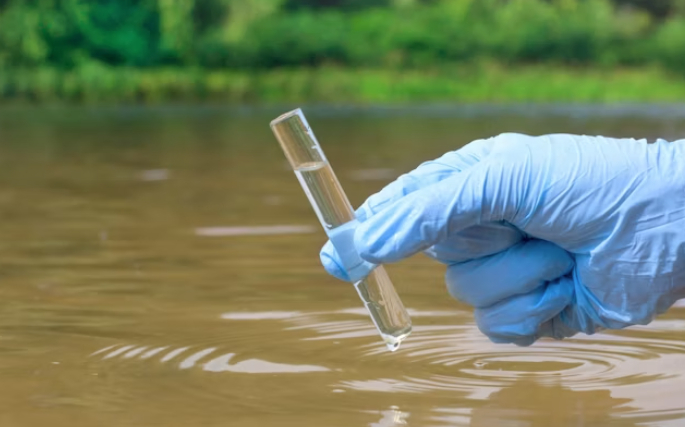



### The Second Stage

* 1- Aapplied SMOTE
* 2- We used classic Machine Learning
 * KNN
 * TD
 * MLP
 * TD-ABC
 * TD-GWO
 * TD-TSO
* 3- To evaluate the performance or quality of the model different performances such as Accuracy, Precision, Recall, F1 Score, MCC, ROC,confusion matrix, True positive, False positive, False negative and True negative

* 4- To classification of Water quality:
 * Safe
 * No-safe


* Applied GUI  Water Quality Prediction System


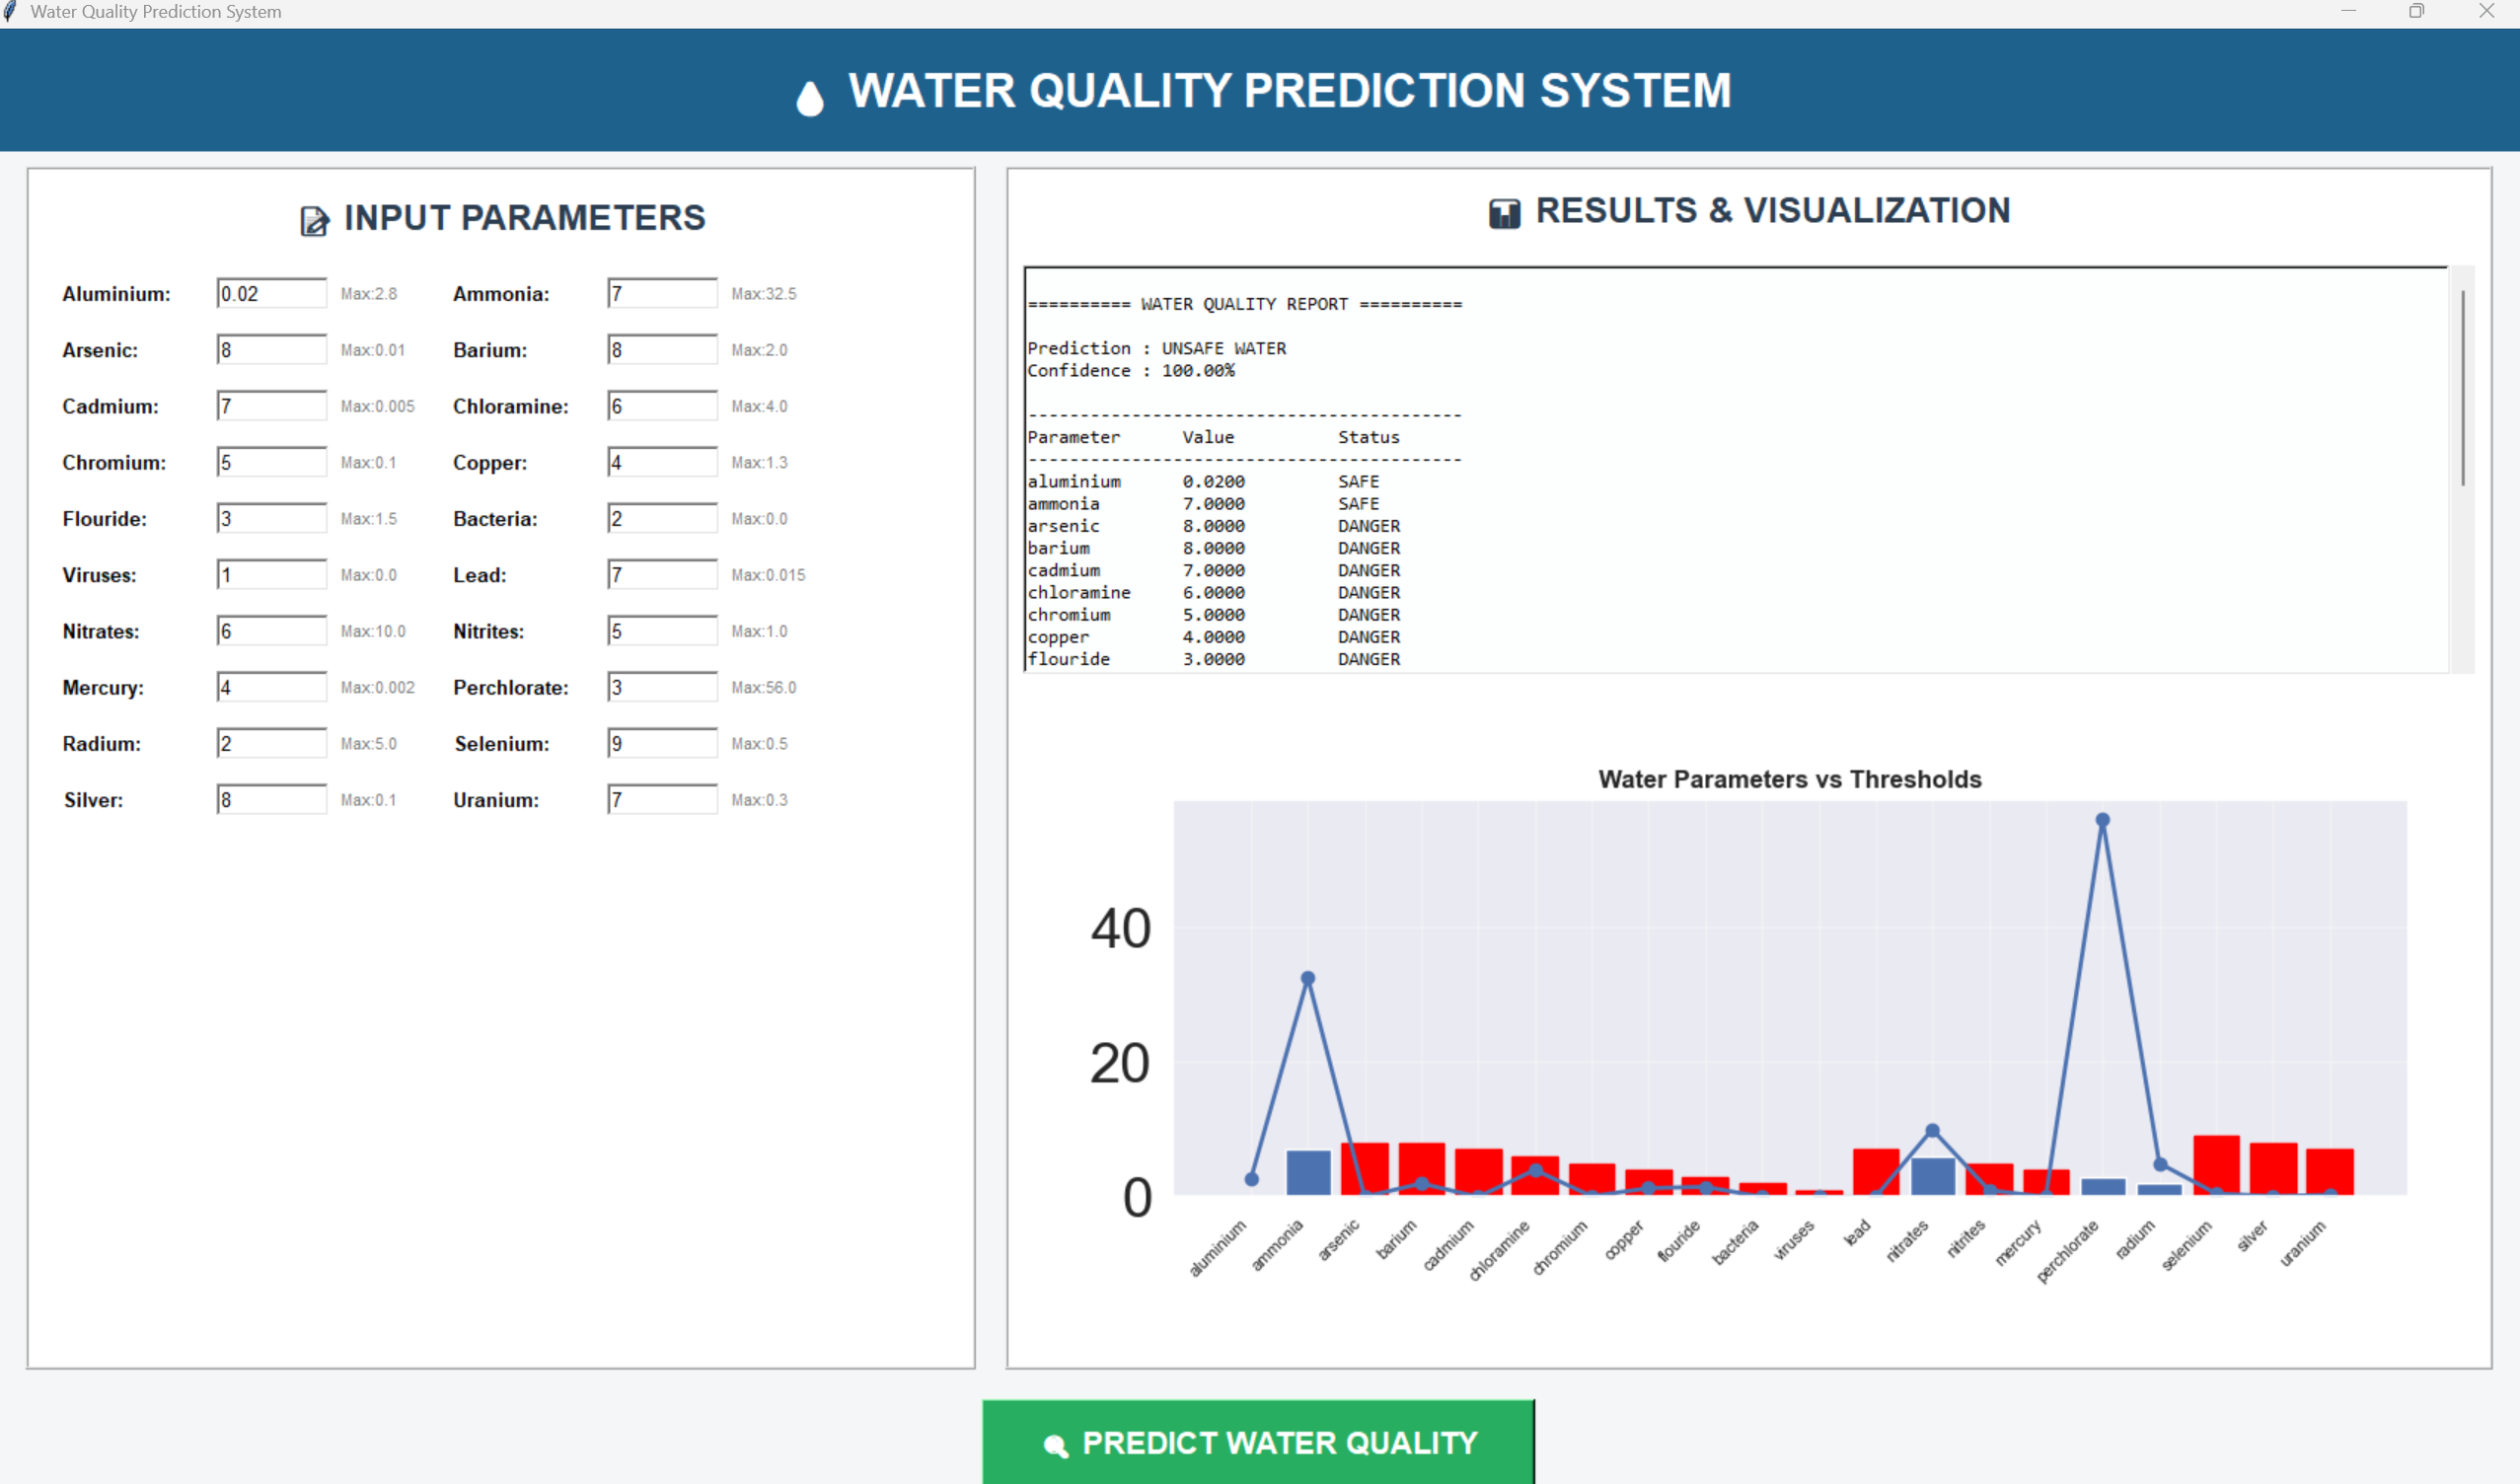


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import statsmodels.api as sm
import seaborn as sns
from collections import Counter
import time
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
#%matplotlib inline
#sns.set(rc={'figure.figsize': [12, 8]}, font_scale=2.4)
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('waterQuality1.csv')
df.head(5)# the first 5 rows

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [3]:
df.describe().T # we see count,	unique,	top, and freq each columns

,count,mean,std,min,25%,50%,75%,max
aluminium,7999.0,0.666158,1.265145,0.0,0.040,0.070,0.280,5.05
arsenic,7999.0,0.161445,0.252590,0.0,0.030,0.050,0.100,1.05
barium,7999.0,1.567715,1.216091,0.0,0.560,1.190,2.480,4.94
cadmium,7999.0,0.042806,0.036049,0.0,0.008,0.040,0.070,0.13
chloramine,7999.0,2.176831,2.567027,0.0,0.100,0.530,4.240,8.68
chromium,7999.0,0.247226,0.270640,0.0,0.050,0.090,0.440,0.90
copper,7999.0,0.805857,0.653539,0.0,0.090,0.750,1.390,2.00
flouride,7999.0,0.771565,0.435373,0.0,0.405,0.770,1.160,1.50
bacteria,7999.0,0.319665,0.329485,0.0,0.000,0.220,0.610,1.00
viruses,7999.0,0.328583,0.378096,0.0,0.002,0.008,0.700,1.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   object 
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uraniu

In [5]:
df.isnull().sum()

aluminium      0
ammonia        0
arsenic        0
barium         0
cadmium        0
chloramine     0
chromium       0
copper         0
flouride       0
bacteria       0
viruses        0
lead           0
nitrates       0
nitrites       0
mercury        0
perchlorate    0
radium         0
selenium       0
silver         0
uranium        0
is_safe        0
dtype: int64

In [6]:
df  = df.replace('#NUM!',0)
df['ammonia'] = df['ammonia'].astype(float)
df['is_safe'] = df['is_safe'].astype(int)

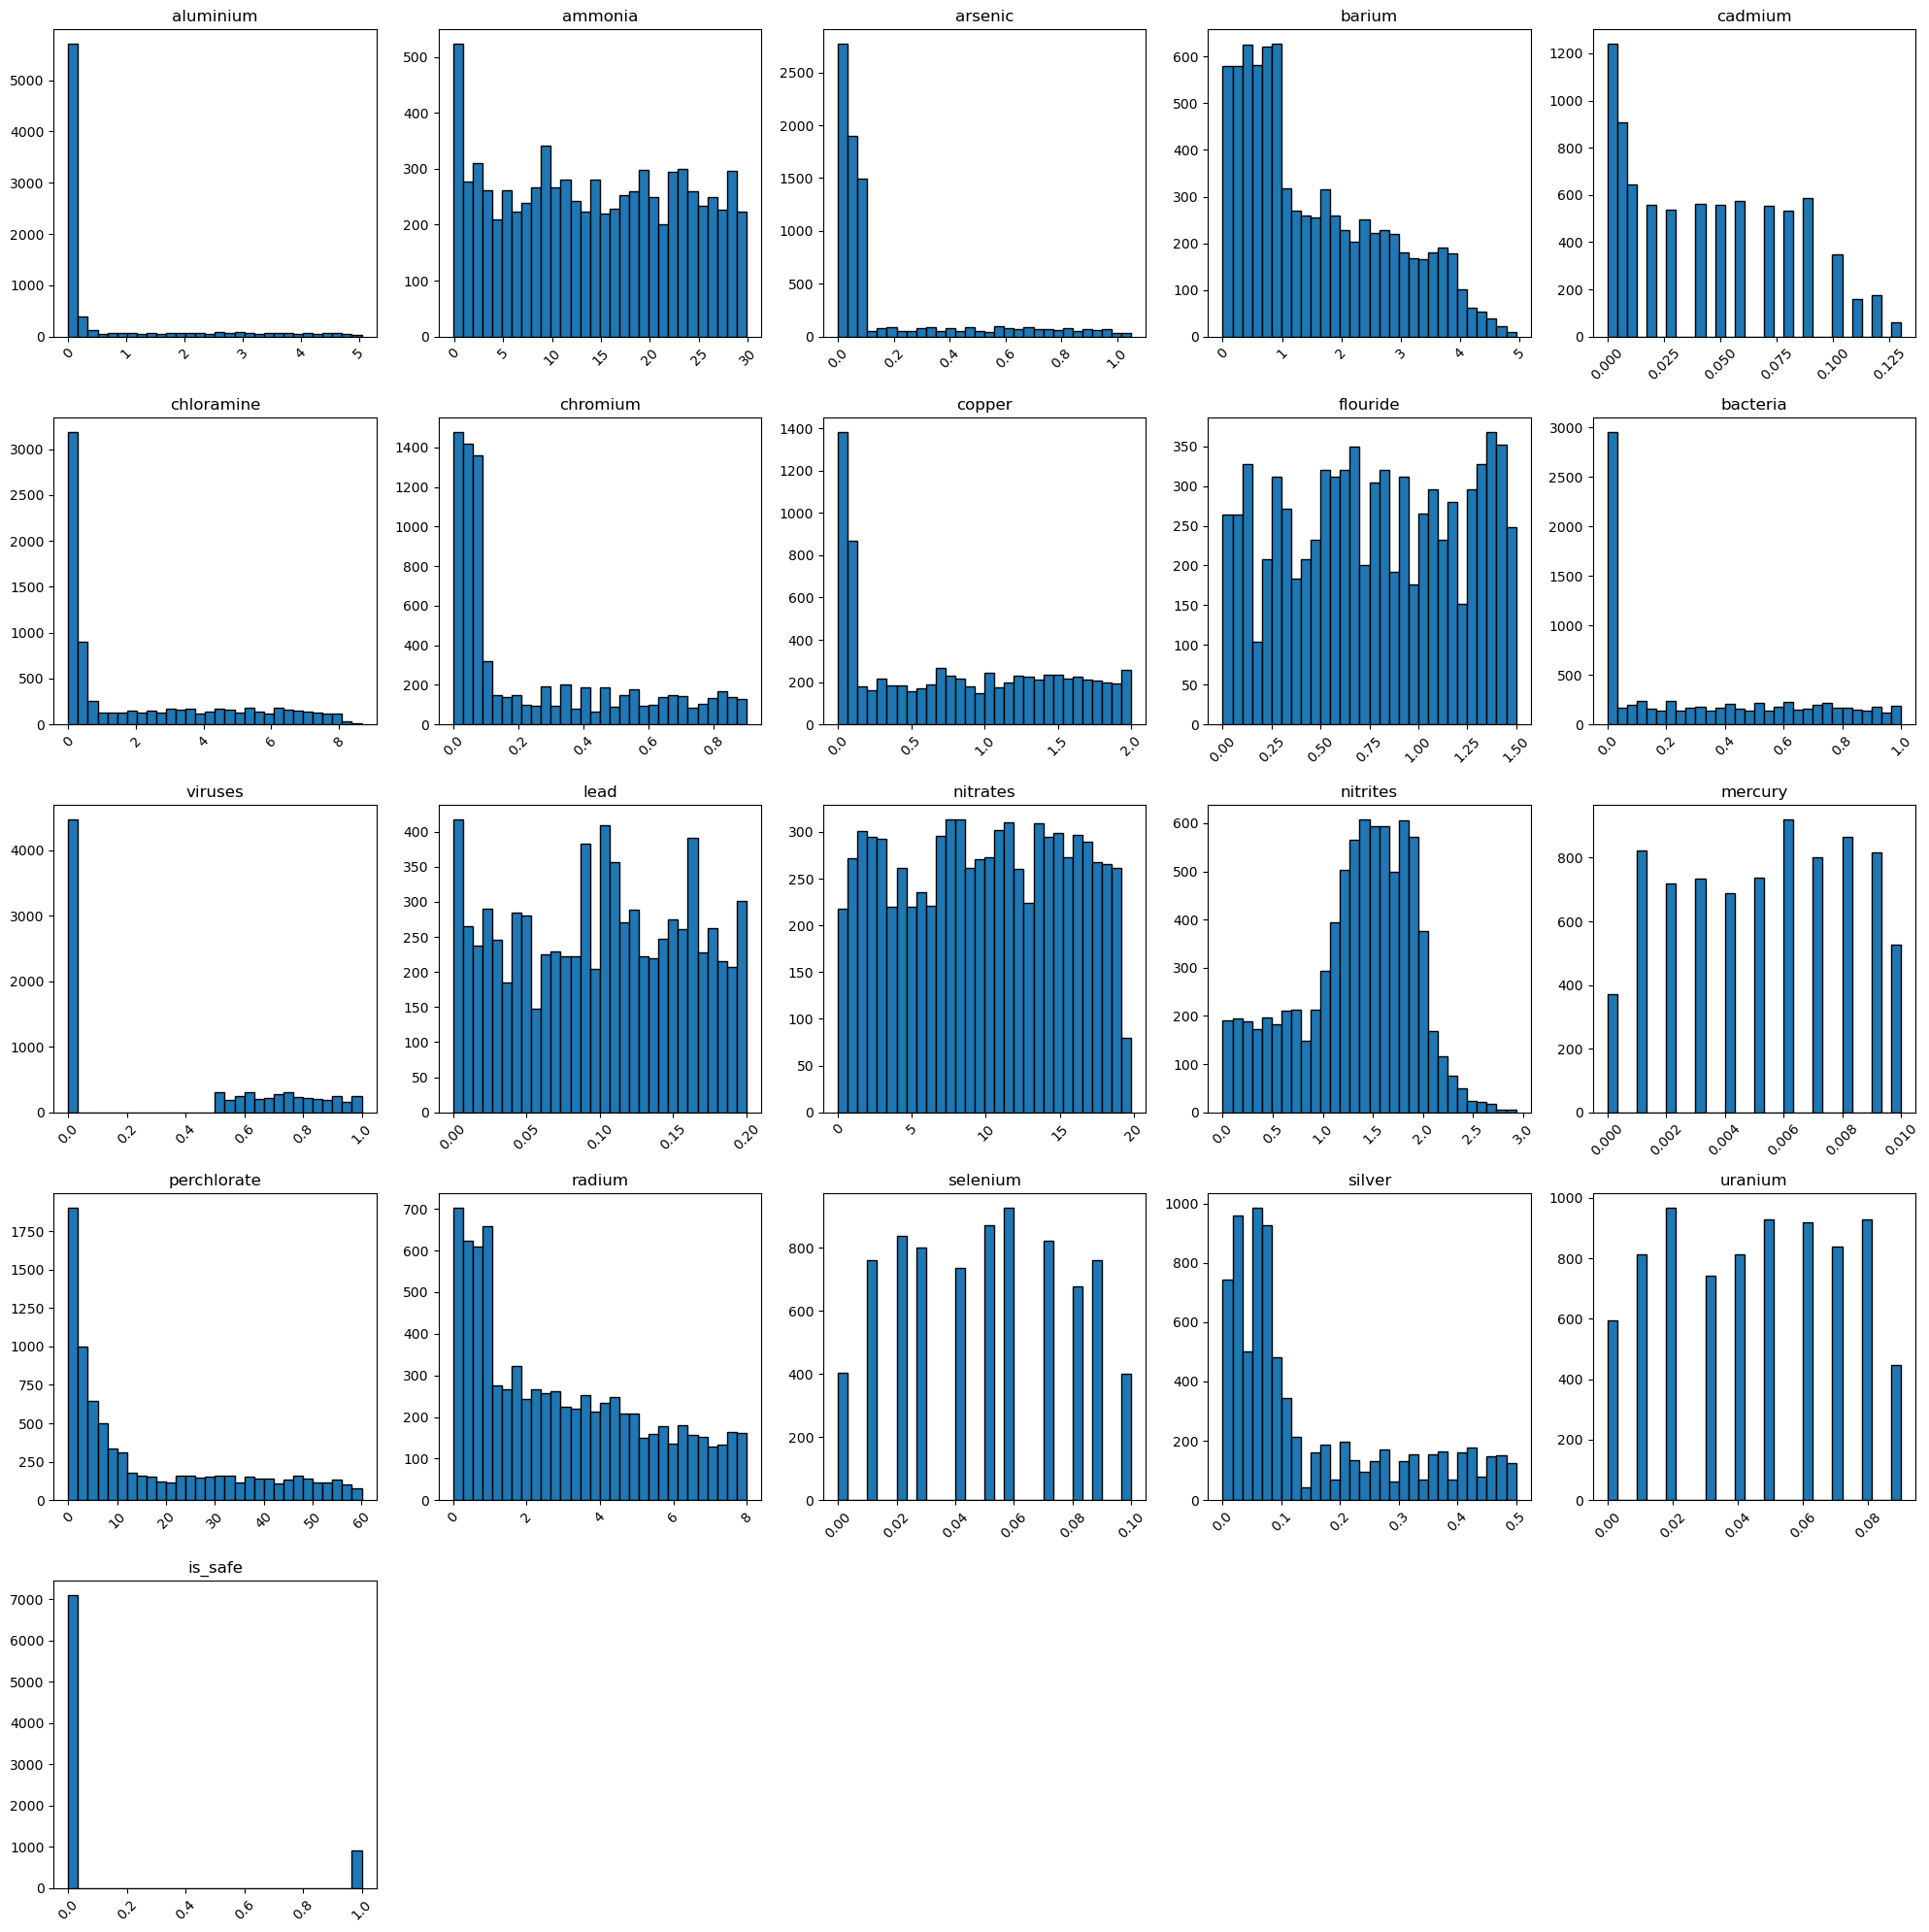

In [7]:
import matplotlib.pyplot as plt
import numpy as np

df_num = df.select_dtypes(include=np.number)
n_cols = 5
n_features = len(df_num.columns)
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    axes[i].hist(df_num[col], bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


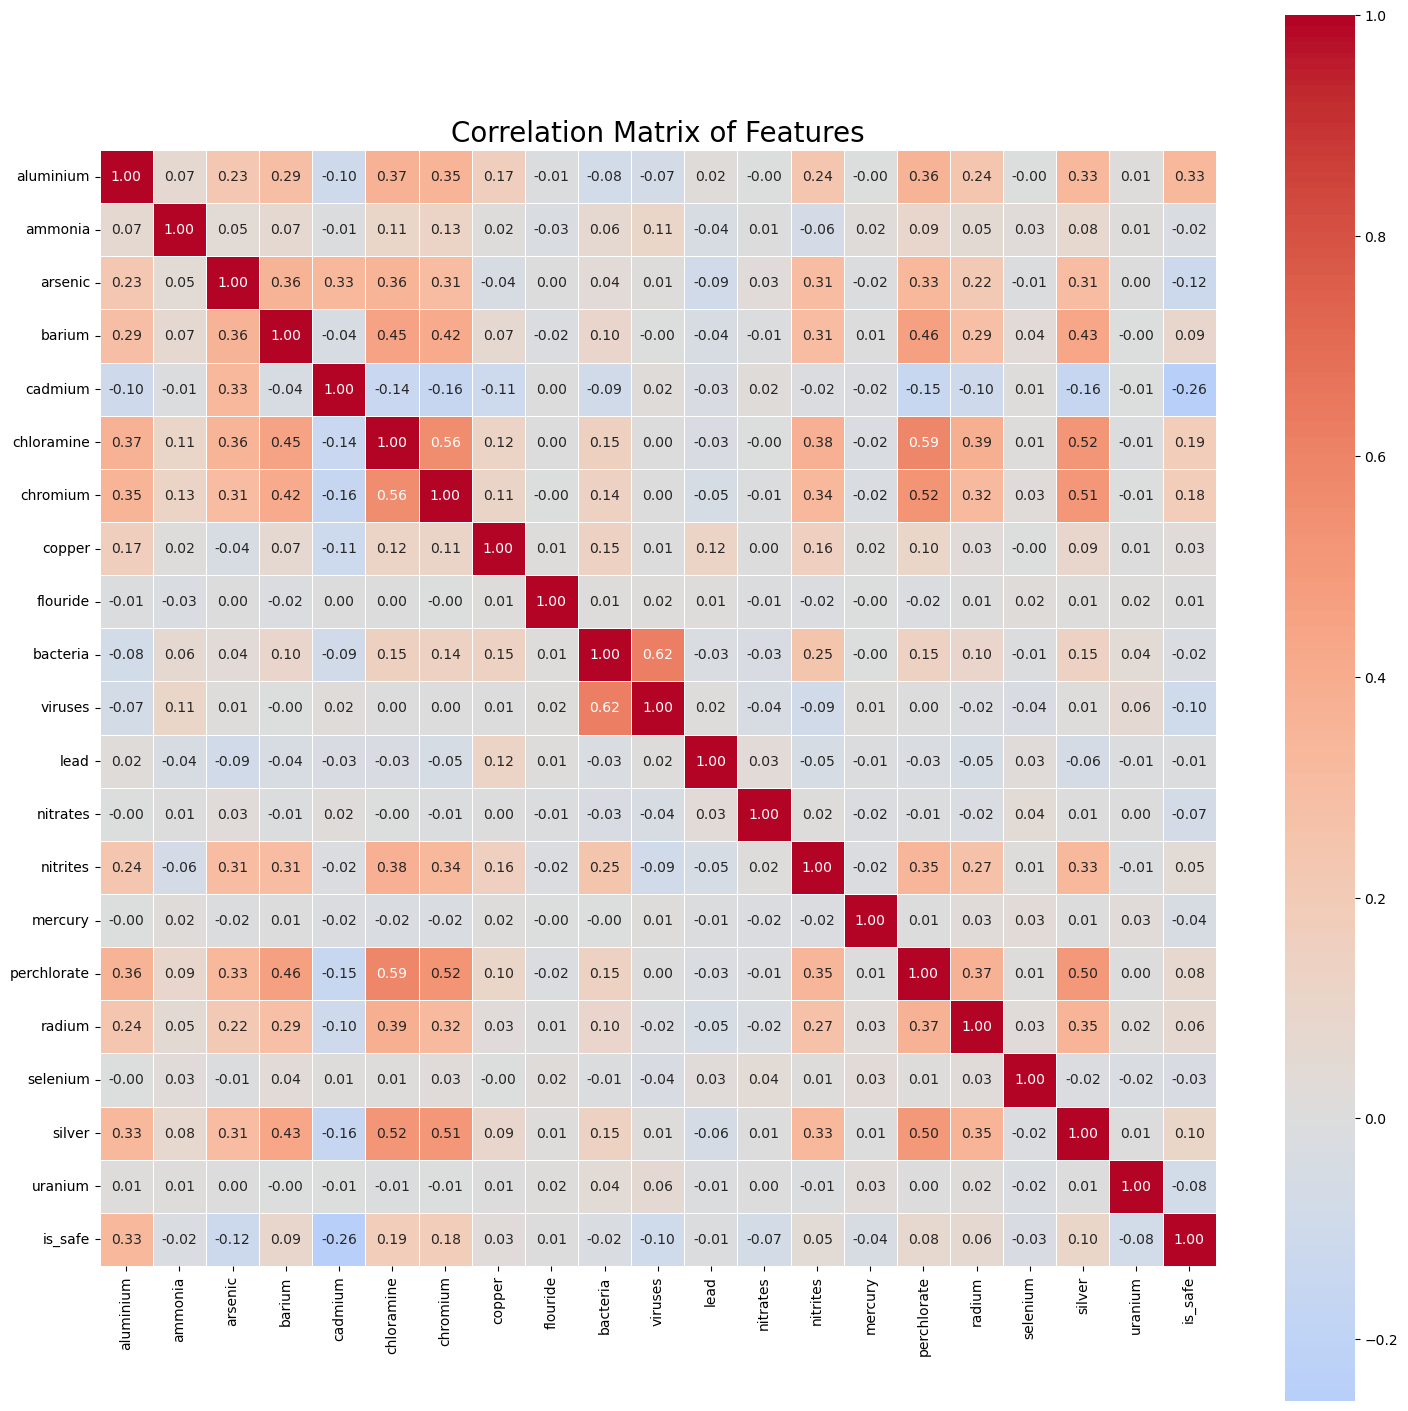

In [8]:
# Generate correlation matrix and heatmap
fig, ax = plt.subplots(figsize=(18, 18))
sns.heatmap(df.corr(), ax=ax, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)

# Add title
plt.title('Correlation Matrix of Features', fontsize=20)

# Save figure to file (adjust filename and format as needed)
plt.savefig('correlation_matrix_heatmap.png', dpi=300, bbox_inches='tight', 
            pad_inches=0.5, facecolor='white')

In [9]:
df

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7994,0.05,7.78,0.00,1.95,0.040,0.10,0.03,0.03,1.37,0.00,...,0.197,14.29,1.00,0.005,3.57,2.13,0.09,0.06,0.03,1
7995,0.05,24.22,0.02,0.59,0.010,0.45,0.02,0.02,1.48,0.00,...,0.031,10.27,1.00,0.001,1.48,1.11,0.09,0.10,0.08,1
7996,0.09,6.85,0.00,0.61,0.030,0.05,0.05,0.02,0.91,0.00,...,0.182,15.92,1.00,0.000,1.35,4.84,0.00,0.04,0.05,1
7997,0.01,10.00,0.01,2.00,0.000,2.00,0.00,0.09,0.00,0.00,...,0.000,0.00,0.00,0.000,0.00,0.00,0.00,0.00,0.00,1


In [10]:
x = df.drop('is_safe', axis=1)
y = df['is_safe']

In [11]:
# setting up testing and training sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=25)

In [12]:
x

,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,viruses,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,0.000,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,0.650,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,0.003,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,0.710,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,0.001,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7994,0.05,7.78,0.00,1.95,0.040,0.10,0.03,0.03,1.37,0.00,0.000,0.197,14.29,1.00,0.005,3.57,2.13,0.09,0.06,0.03
7995,0.05,24.22,0.02,0.59,0.010,0.45,0.02,0.02,1.48,0.00,0.000,0.031,10.27,1.00,0.001,1.48,1.11,0.09,0.10,0.08
7996,0.09,6.85,0.00,0.61,0.030,0.05,0.05,0.02,0.91,0.00,0.000,0.182,15.92,1.00,0.000,1.35,4.84,0.00,0.04,0.05
7997,0.01,10.00,0.01,2.00,0.000,2.00,0.00,0.09,0.00,0.00,0.000,0.000,0.00,0.00,0.000,0.00,0.00,0.00,0.00,0.00


Original dataset shape : Counter({0: 7087, 1: 912})


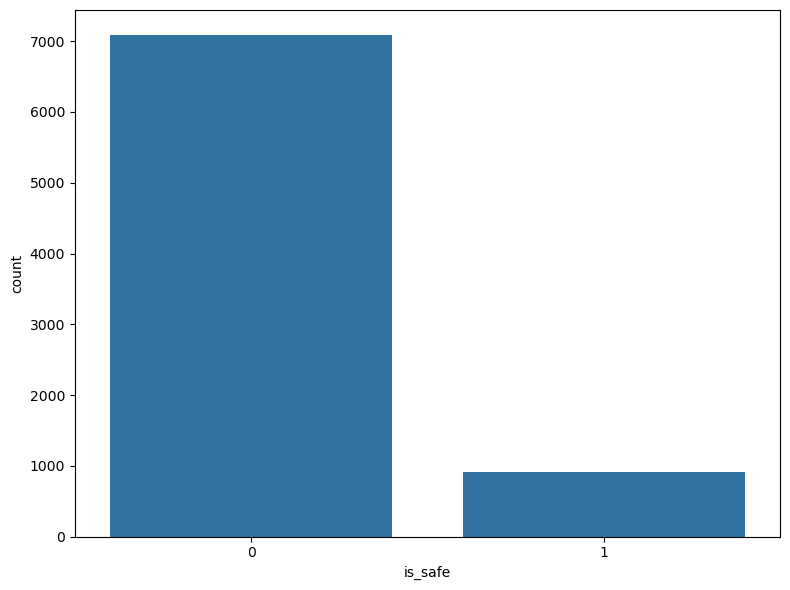

In [13]:
plt.figure(figsize=(8,6))
sns.countplot(x=y,data=df)
print(f'Original dataset shape : {Counter(y)}')
plt.tight_layout()
plt.show()

In [14]:
from imblearn.over_sampling import SMOTE 
from collections import Counter

rus = SMOTE(random_state=42)
X_train, y_train = rus.fit_resample(X_train, y_train)

print(f"Resampled dataset shape: {Counter(y_train)}")


Resampled dataset shape: Counter({0: 5651, 1: 5651})


Resampled dataset shape Counter({0: 5651, 1: 5651})


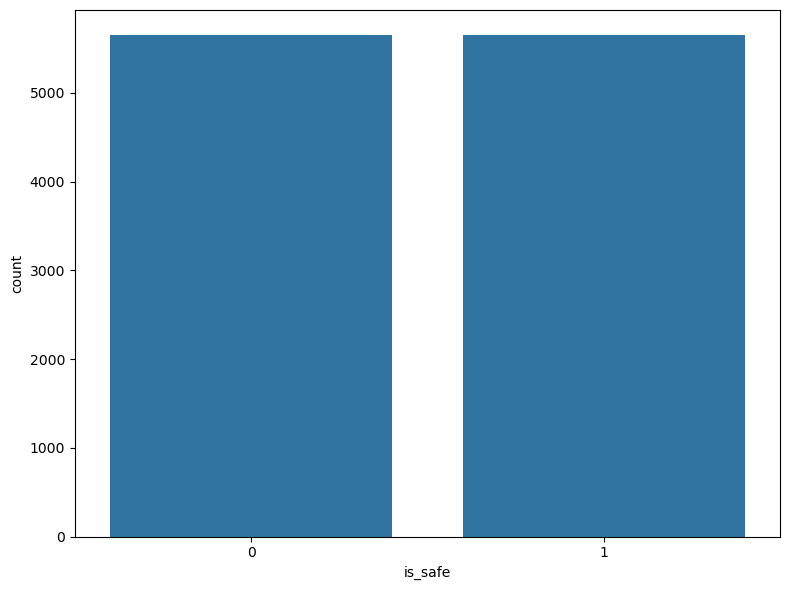

In [15]:
plt.figure(figsize=(8,6))
sns.countplot(x=y_train,data=df)
print(f'Resampled dataset shape {Counter(y_train)}')
plt.tight_layout()
plt.show()


 Total Execution Time (Train + Test): 0.0848 seconds

Training Accuracy: 0.9017872942841975
Testing Accuracy: 0.75625


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.77      0.85      1436
           1       0.25      0.67      0.36       164

    accuracy                           0.76      1600
   macro avg       0.60      0.72      0.61      1600
weighted avg       0.88      0.76      0.80      1600

Accuracy Score: 0.75625
Precision Score: 0.5999215052342797
Recall Score: 0.7183742102044977
F1 Score: 0.6050382935628837
Matthews Correlation Coefficient: 0.2954337813316575

*******************************************

[[1100  336]
 [  54  110]]
True positive =  110
False positive =  336
False negative =  54
True negative =  1100

*******************************************



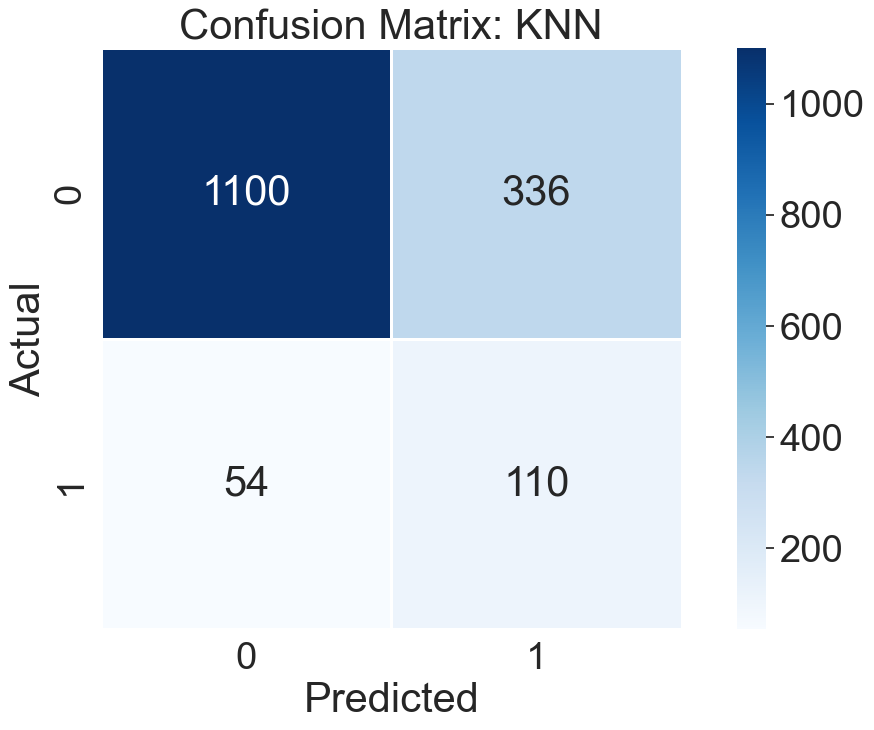


*******************************************

AUC Score = 0.718


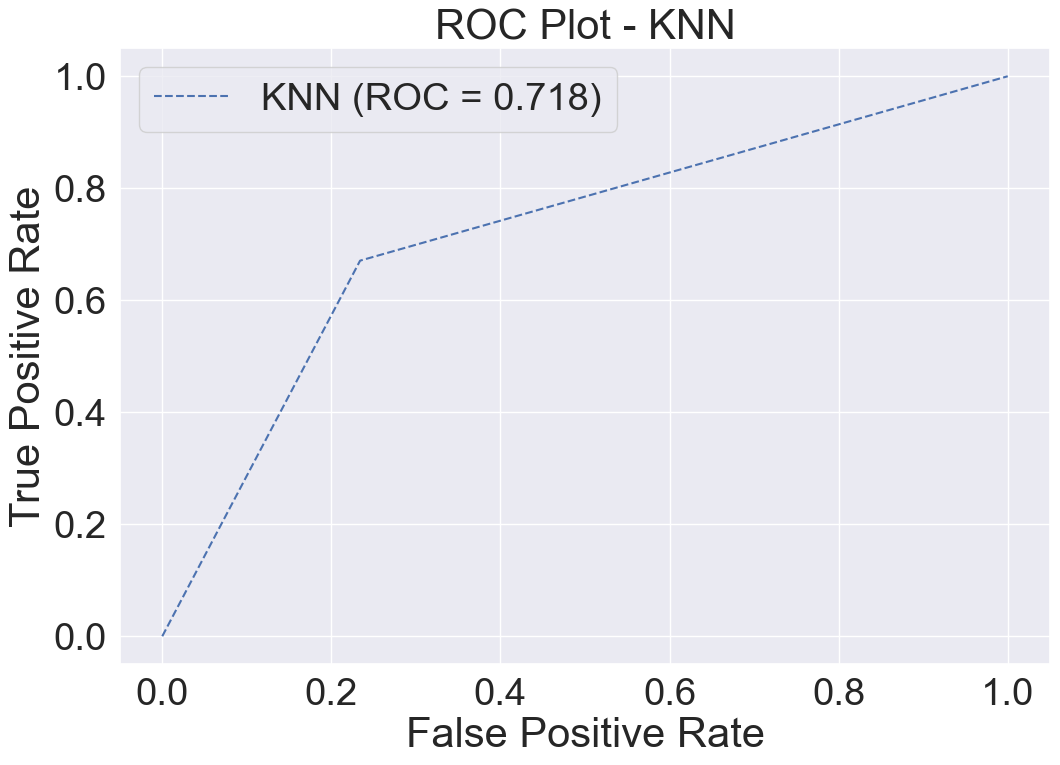

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import matthews_corrcoef, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import classification_report
import time
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------------
#                  TIME START
# --------------------------------------------------------------
start_time = time.time()

# ---------------- KNN CLASSIFIER ------------------------------
# You can adjust n_neighbors value as needed (default is 5)
model_knn = KNeighborsClassifier(n_neighbors=5)

# Train model
model_knn.fit(X_train, y_train)

# Predict
predictions_knn = model_knn.predict(X_test)

# --------------------------------------------------------------
#                  TIME END
# --------------------------------------------------------------
end_time = time.time()
execution_time = end_time - start_time
print(f"\n Total Execution Time (Train + Test): {execution_time:.4f} seconds\n")

# --------------------------------------------------------------
#                TRAIN & TEST ACCURACY
# --------------------------------------------------------------
train_accuracy = accuracy_score(y_train, model_knn.predict(X_train))
test_accuracy = accuracy_score(y_test, predictions_knn)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("\n")

# --------------------------------------------------------------
#                CLASSIFICATION REPORT
# --------------------------------------------------------------
report = classification_report(y_test, predictions_knn)
print("Classification Report:")
print(report)

# --------------------------------------------------------------
#                METRICS
# --------------------------------------------------------------
accuracy_knn = accuracy_score(y_test, predictions_knn)
precision_knn = precision_score(y_test, predictions_knn, average='macro')
recall_knn = recall_score(y_test, predictions_knn, average='macro')
f1_knn = f1_score(y_test, predictions_knn, average='macro')
mcc_knn = matthews_corrcoef(y_test, predictions_knn)

print("Accuracy Score:", accuracy_knn)
print("Precision Score:", precision_knn)
print("Recall Score:", recall_knn)
print("F1 Score:", f1_knn)
print("Matthews Correlation Coefficient:", mcc_knn)
print("\n*******************************************\n")

# --------------------------------------------------------------
#                CONFUSION MATRIX
# --------------------------------------------------------------
conf_matrix = confusion_matrix(y_test, predictions_knn)
print(conf_matrix)

TN, FP, FN, TP = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]

print('True positive = ', TP)
print('False positive = ', FP)
print('False negative = ', FN)
print('True negative = ', TN)

print("\n*******************************************\n")

# Plot Confusion Matrix
plt.figure(figsize=(12, 8))
sns.set(font_scale=2.5)

sns.heatmap(conf_matrix, annot=True, annot_kws={'size':30},
            fmt=".0f", square=True, cmap=plt.cm.Blues, linewidths=0.8)

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: KNN')
plt.tight_layout()
plt.show()

print("\n*******************************************\n")

# --------------------------------------------------------------
#                ROC & AUC
# --------------------------------------------------------------
knn_auc = roc_auc_score(y_test, predictions_knn)
print(f'AUC Score = {knn_auc:.3f}')

knn_fpr, knn_tpr, _ = roc_curve(y_test, predictions_knn)

plt.figure(figsize=(12, 8))
plt.plot(knn_fpr, knn_tpr, linestyle='--',
         label='KNN (ROC = %0.3f)' % knn_auc)

plt.title('ROC Plot - KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


 Total Execution Time (Train + Test): 0.0818 seconds

Training Accuracy: 0.9178906388249868
Testing Accuracy: 0.88125


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1436
           1       0.46      0.88      0.60       164

    accuracy                           0.88      1600
   macro avg       0.72      0.88      0.77      1600
weighted avg       0.93      0.88      0.90      1600

Accuracy Score: 0.88125
Precision Score: 0.7215233132906063
Recall Score: 0.8798321896867993
F1 Score: 0.7663544218962799
Matthews Correlation Coefficient: 0.5801437241023844

*******************************************

[[1266  170]
 [  20  144]]
True positive =  144
False positive =  170
False negative =  20
True negative =  1266

*******************************************



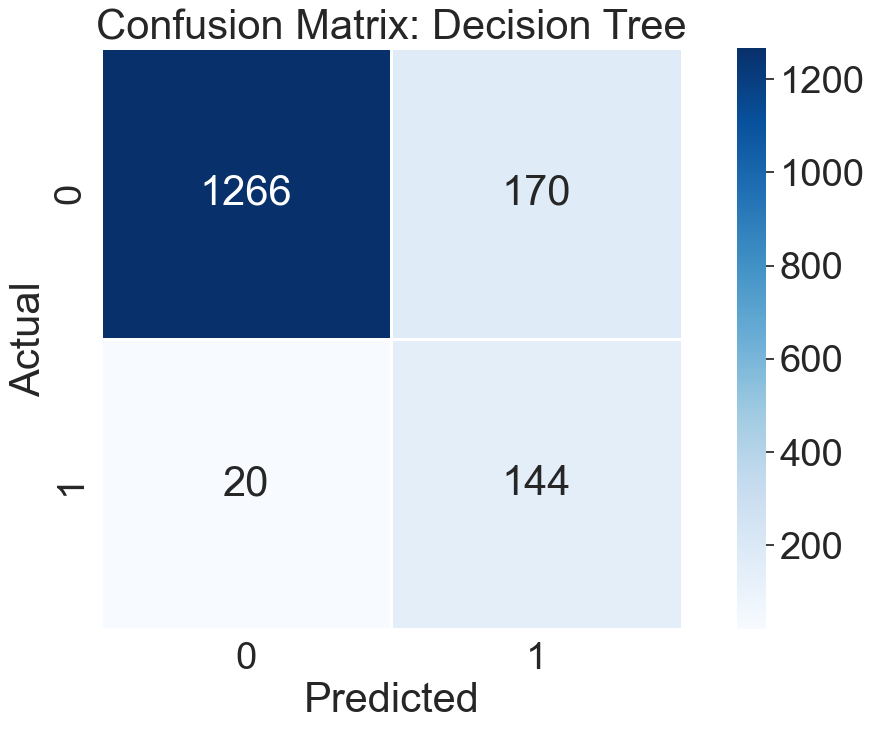


*******************************************

AUC Score = 0.880


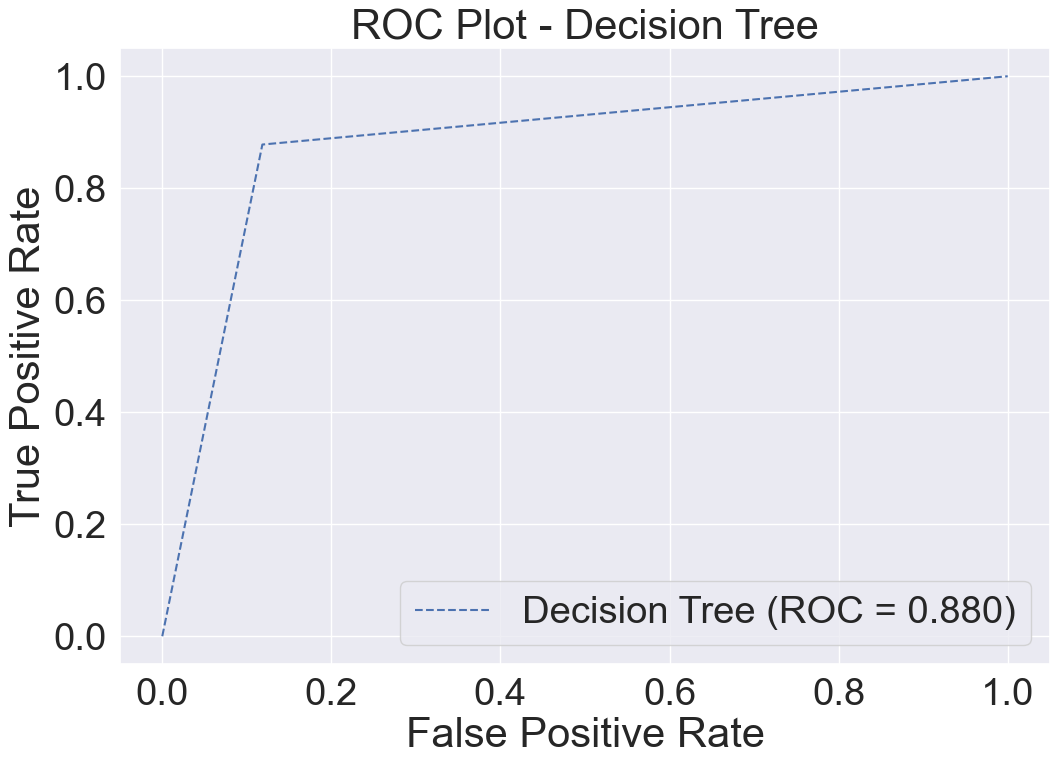

In [17]:
from sklearn.tree import DecisionTreeClassifier
# --------------------------------------------------------------
#                  TIME START
# --------------------------------------------------------------
start_time = time.time()

# ---------------- DECISION TREE CLASSIFIER --------------------
model_dt = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

# Train model
model_dt.fit(X_train, y_train)

# Predict
predictions_dt = model_dt.predict(X_test)

# --------------------------------------------------------------
#                  TIME END
# --------------------------------------------------------------
end_time = time.time()
execution_time = end_time - start_time
print(f"\n Total Execution Time (Train + Test): {execution_time:.4f} seconds\n")

# --------------------------------------------------------------
#                TRAIN & TEST ACCURACY
# --------------------------------------------------------------
train_accuracy = accuracy_score(y_train, model_dt.predict(X_train))
test_accuracy = accuracy_score(y_test, predictions_dt)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("\n")

# --------------------------------------------------------------
#                CLASSIFICATION REPORT
# --------------------------------------------------------------
report = classification_report(y_test, predictions_dt)
print("Classification Report:")
print(report)

# --------------------------------------------------------------
#                METRICS
# --------------------------------------------------------------
accuracy_dt = accuracy_score(y_test, predictions_dt)
precision_dt = precision_score(y_test, predictions_dt, average='macro')
recall_dt = recall_score(y_test, predictions_dt, average='macro')
f1_dt = f1_score(y_test, predictions_dt, average='macro')
mcc_dt = matthews_corrcoef(y_test, predictions_dt)

print("Accuracy Score:", accuracy_dt)
print("Precision Score:", precision_dt)
print("Recall Score:", recall_dt)
print("F1 Score:", f1_dt)
print("Matthews Correlation Coefficient:", mcc_dt)
print("\n*******************************************\n")

# --------------------------------------------------------------
#                CONFUSION MATRIX
# --------------------------------------------------------------
conf_matrix = confusion_matrix(y_test, predictions_dt)
print(conf_matrix)

TN, FP, FN, TP = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]

print('True positive = ', TP)
print('False positive = ', FP)
print('False negative = ', FN)
print('True negative = ', TN)

print("\n*******************************************\n")

# Plot Confusion Matrix
plt.figure(figsize=(12, 8))
sns.set(font_scale=2.5)

sns.heatmap(conf_matrix, annot=True, annot_kws={'size':30},
            fmt=".0f", square=True, cmap=plt.cm.Blues, linewidths=0.8)

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Decision Tree')
plt.tight_layout()
plt.show()

print("\n*******************************************\n")

# --------------------------------------------------------------
#                ROC & AUC
# --------------------------------------------------------------
dt_auc = roc_auc_score(y_test, predictions_dt)
print(f'AUC Score = {dt_auc:.3f}')

dt_fpr, dt_tpr, _ = roc_curve(y_test, predictions_dt)

plt.figure(figsize=(12, 8))
plt.plot(dt_fpr, dt_tpr, linestyle='--',
         label='Decision Tree (ROC = %0.3f)' % dt_auc)

plt.title('ROC Plot - Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


 Total Execution Time (Train + Test): 8.0196 seconds

Training Accuracy: 0.9762873827641125
Testing Accuracy: 0.934375


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1436
           1       0.64      0.82      0.72       164

    accuracy                           0.93      1600
   macro avg       0.81      0.89      0.84      1600
weighted avg       0.94      0.93      0.94      1600

Accuracy Score: 0.934375
Precision Score: 0.8094660484033315
Recall Score: 0.885122970310483
F1 Score: 0.8414159292035398
Matthews Correlation Coefficient: 0.6904563238072013

*******************************************

[[1360   76]
 [  29  135]]
True positive =  135
False positive =  76
False negative =  29
True negative =  1360

*******************************************



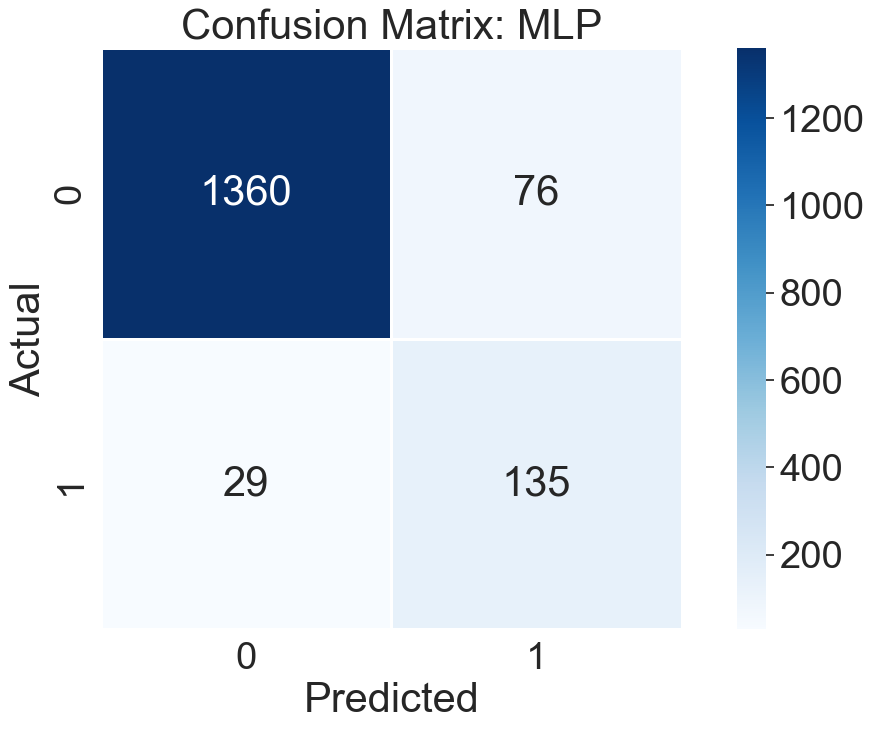


*******************************************

AUC Score = 0.885


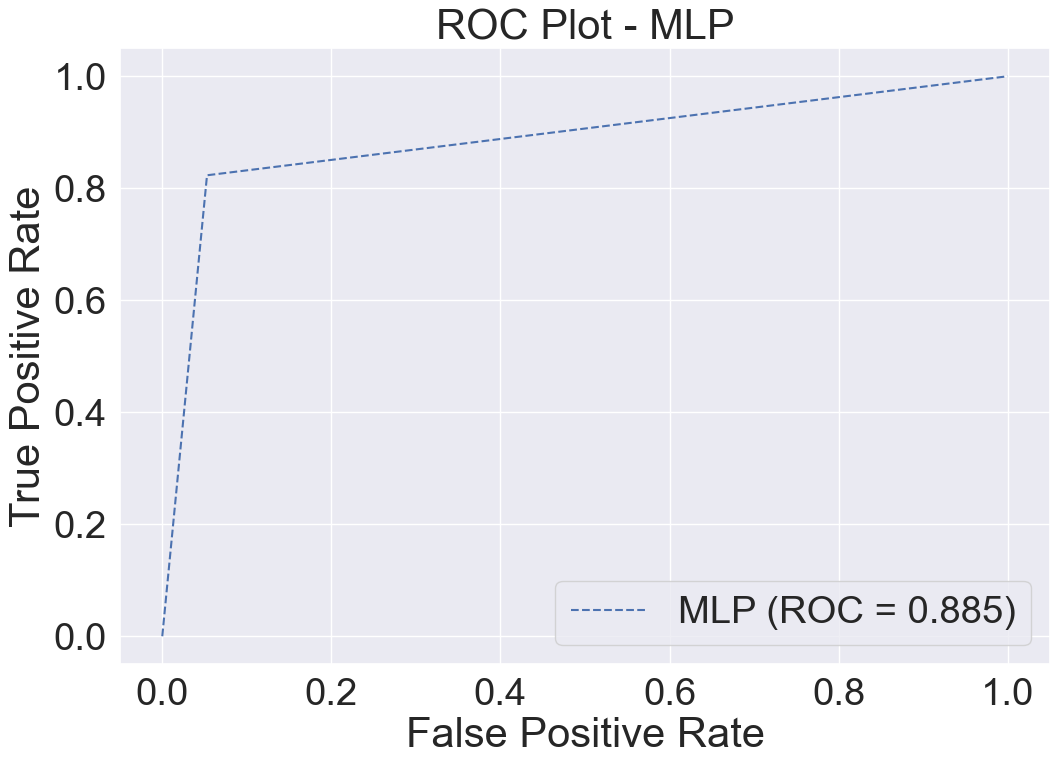

In [18]:
from sklearn.neural_network import MLPClassifier
# --------------------------------------------------------------
#                 TIME START
# --------------------------------------------------------------
start_time = time.time()

# ---------------- MLP CLASSIFIER ------------------------------
# You can adjust hidden layer sizes, activation function, etc.
model_mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', 
                          solver='adam', max_iter=300, random_state=42)

# Train model
model_mlp.fit(X_train, y_train)

# Predict
predictions_mlp = model_mlp.predict(X_test)

# --------------------------------------------------------------
#                 TIME END
# --------------------------------------------------------------
end_time = time.time()
execution_time = end_time - start_time
print(f"\n Total Execution Time (Train + Test): {execution_time:.4f} seconds\n")

# --------------------------------------------------------------
#                TRAIN & TEST ACCURACY
# --------------------------------------------------------------
train_accuracy = accuracy_score(y_train, model_mlp.predict(X_train))
test_accuracy = accuracy_score(y_test, predictions_mlp)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("\n")

# --------------------------------------------------------------
#                CLASSIFICATION REPORT
# --------------------------------------------------------------
report = classification_report(y_test, predictions_mlp)
print("Classification Report:")
print(report)

# --------------------------------------------------------------
#                METRICS
# --------------------------------------------------------------
accuracy_mlp = accuracy_score(y_test, predictions_mlp)
precision_mlp = precision_score(y_test, predictions_mlp, average='macro')
recall_mlp = recall_score(y_test, predictions_mlp, average='macro')
f1_mlp = f1_score(y_test, predictions_mlp, average='macro')
mcc_mlp = matthews_corrcoef(y_test, predictions_mlp)

print("Accuracy Score:", accuracy_mlp)
print("Precision Score:", precision_mlp)
print("Recall Score:", recall_mlp)
print("F1 Score:", f1_mlp)
print("Matthews Correlation Coefficient:", mcc_mlp)
print("\n*******************************************\n")

# --------------------------------------------------------------
#                CONFUSION MATRIX
# --------------------------------------------------------------
conf_matrix = confusion_matrix(y_test, predictions_mlp)
print(conf_matrix)

TN, FP, FN, TP = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]

print('True positive = ', TP)
print('False positive = ', FP)
print('False negative = ', FN)
print('True negative = ', TN)

print("\n*******************************************\n")

# Plot Confusion Matrix
plt.figure(figsize=(12, 8))
sns.set(font_scale=2.5)

sns.heatmap(conf_matrix, annot=True, annot_kws={'size':30},
            fmt=".0f", square=True, cmap=plt.cm.Blues, linewidths=0.8)

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: MLP')
plt.tight_layout()
plt.show()

print("\n*******************************************\n")

# --------------------------------------------------------------
#                ROC & AUC
# --------------------------------------------------------------
mlp_auc = roc_auc_score(y_test, predictions_mlp)
print(f'AUC Score = {mlp_auc:.3f}')

mlp_fpr, mlp_tpr, _ = roc_curve(y_test, predictions_mlp)

plt.figure(figsize=(12, 8))
plt.plot(mlp_fpr, mlp_tpr, linestyle='--',
         label='MLP (ROC = %0.3f)' % mlp_auc)

plt.title('ROC Plot - MLP')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Initial Best Params = [15.1983539   6.57853529  7.01856157  1.48756965] Fitness = 0.9475
Iteration 1/10 — Best Fitness = 0.9487
Iteration 2/10 — Best Fitness = 0.9487
Iteration 3/10 — Best Fitness = 0.9487
Iteration 4/10 — Best Fitness = 0.9494
Iteration 5/10 — Best Fitness = 0.9494
Iteration 6/10 — Best Fitness = 0.9494
Iteration 7/10 — Best Fitness = 0.9494
Iteration 8/10 — Best Fitness = 0.9494
Iteration 9/10 — Best Fitness = 0.9494
Iteration 10/10 — Best Fitness = 0.9494

 BEST PARAMETERS (ABC)
max_depth = 20
min_samples_split = 13
min_samples_leaf = 7
criterion = log_loss
Best Accuracy = 0.949375

Training Time: 0.1676 seconds
Testing Time: 0.0010 seconds
Total Execution Time (Train + Test): 0.1686 seconds

Training Accuracy: 0.9813
Testing Accuracy: 0.9494


===== FINAL MODEL PERFORMANCE =====
Accuracy: 0.949375
Precision: 0.8453710717321186
Recall: 0.9123836537808274
F1 Score: 0.8747553816046967
MCC: 0.7547857562807907

===== CLASSIFICATION REPORT =====
              precision  

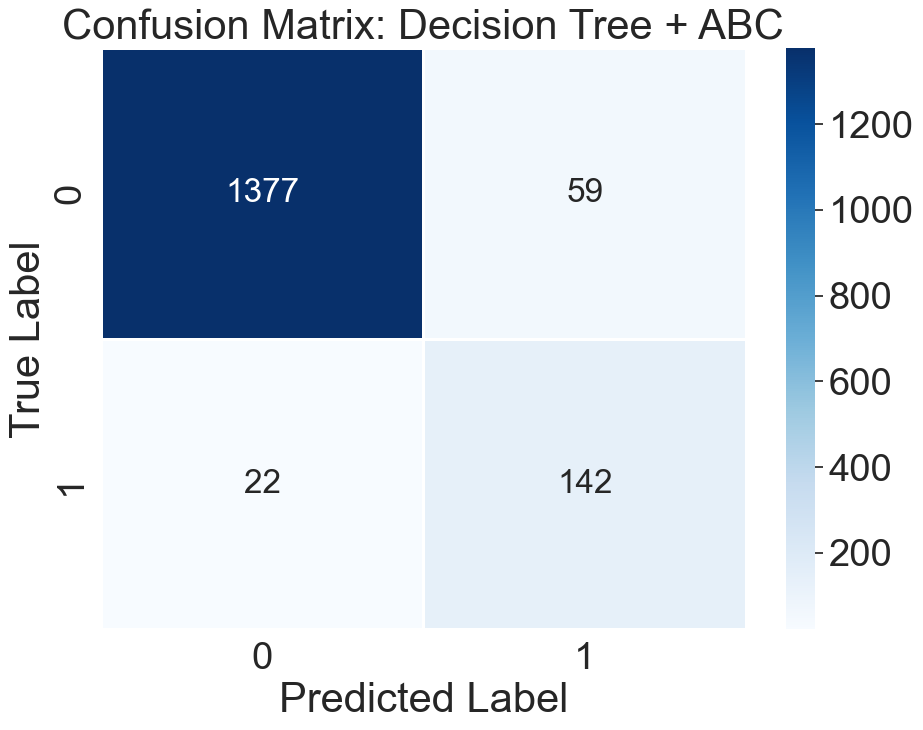


ROC AUC = 0.9123836537808274


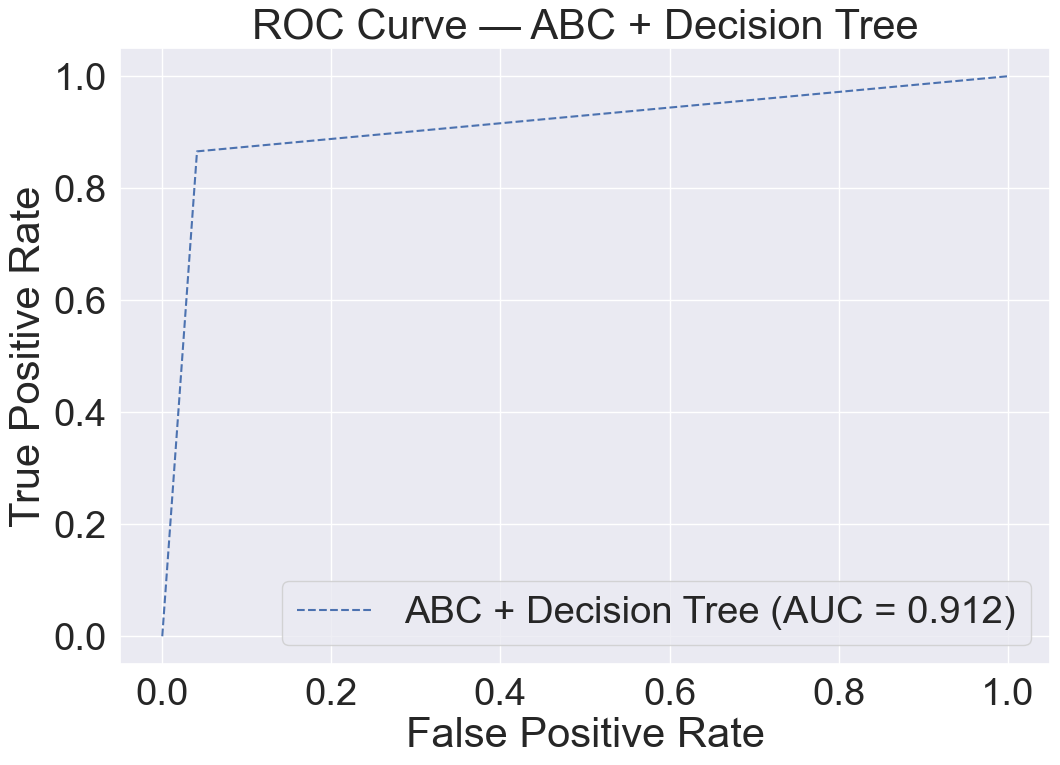

In [19]:
# ============================================================
#               FITNESS FUNCTION (Decision Tree)
# ============================================================
def fitness_function(params, X_train, y_train, X_test, y_test):
    
    max_depth = int(params[0])
    min_samples_split = int(params[1])
    min_samples_leaf = int(params[2])
    criterion_idx = int(round(params[3]))  # Round to nearest integer (0, 1, or 2)
    
    # Map index to criterion string
    criterion_map = {0: 'gini', 1: 'entropy', 2: 'log_loss'}
    criterion = criterion_map.get(criterion_idx, 'gini')
    
    model = DecisionTreeClassifier(
        max_depth=max_depth if max_depth > 0 else 1,
        min_samples_split=min_samples_split if min_samples_split >= 2 else 2,
        min_samples_leaf=min_samples_leaf if min_samples_leaf >= 1 else 1,
        criterion=criterion,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    return acc  # maximize accuracy


# ============================================================
#     ARTIFICIAL BEE COLONY (ABC) OPTIMIZATION ALGORITHM
# ============================================================
def bee_algorithm(
    X_train, y_train, X_test, y_test,
    num_bees=5, limit=10, max_iter=10
):
    
    dim = 4   # (max_depth, min_samples_split, min_samples_leaf, criterion)
    
    # Lower & upper bounds
    lb = np.array([1, 2, 1, 0])      # criterion: 0=gini, 1=entropy, 2=log_loss
    ub = np.array([20, 20, 10, 2])   # criterion: 0=gini, 1=entropy, 2=log_loss
    
    # Initialize foods (solutions)
    foods = np.random.uniform(lb, ub, (num_bees, dim))
    fitness = np.zeros(num_bees)
    trial = np.zeros(num_bees)
    
    # Initial fitness evaluation
    for i in range(num_bees):
        fitness[i] = fitness_function(foods[i], X_train, y_train, X_test, y_test)
    
    # Store best
    best_idx = np.argmax(fitness)
    best_food = foods[best_idx].copy()
    best_fitness = fitness[best_idx]
    
    print("Initial Best Params =", best_food, "Fitness =", best_fitness)
    
    # -----------------------------------------------------------
    # ABC MAIN LOOP
    # -----------------------------------------------------------
    for iteration in range(max_iter):
        
        # --------------------------
        # EMPLOYED BEE PHASE
        # --------------------------
        for i in range(num_bees):
            
            k = np.random.randint(num_bees)
            while k == i:
                k = np.random.randint(num_bees)
            
            j = np.random.randint(dim)
            
            new_food = foods[i].copy()
            new_food[j] = foods[i][j] + np.random.uniform(-1, 1) * (foods[i][j] - foods[k][j])
            new_food = np.clip(new_food, lb, ub)
            
            new_fit = fitness_function(new_food, X_train, y_train, X_test, y_test)
            
            if new_fit > fitness[i]:
                foods[i] = new_food
                fitness[i] = new_fit
                trial[i] = 0
            else:
                trial[i] += 1
        
        # --------------------------
        # ONLOOKER BEE PHASE
        # --------------------------
        prob = fitness / fitness.sum()
        
        for _ in range(num_bees):
            i = np.random.choice(range(num_bees), p=prob)
            
            k = np.random.randint(num_bees)
            while k == i:
                k = np.random.randint(num_bees)
            
            j = np.random.randint(dim)
            
            new_food = foods[i].copy()
            new_food[j] = foods[i][j] + np.random.uniform(-1, 1) * (foods[i][j] - foods[k][j])
            new_food = np.clip(new_food, lb, ub)
            
            new_fit = fitness_function(new_food, X_train, y_train, X_test, y_test)
            
            if new_fit > fitness[i]:
                foods[i] = new_food
                fitness[i] = new_fit
                trial[i] = 0
            else:
                trial[i] += 1
        
        # --------------------------
        # SCOUT BEE PHASE
        # --------------------------
        for i in range(num_bees):
            if trial[i] > limit:
                foods[i] = np.random.uniform(lb, ub)
                fitness[i] = fitness_function(foods[i], X_train, y_train, X_test, y_test)
                trial[i] = 0
        
        # Update best
        best_idx = np.argmax(fitness)
        if fitness[best_idx] > best_fitness:
            best_fitness = fitness[best_idx]
            best_food = foods[best_idx].copy()
        
        print(f"Iteration {iteration+1}/{max_iter} — Best Fitness = {best_fitness:.4f}")
    
    return best_food, best_fitness


# ============================================================
#        RUN ABC OPTIMIZATION
# ============================================================
best_params, best_score = bee_algorithm(
    X_train, y_train, X_test, y_test,
    num_bees=5,
    limit=10,
    max_iter=10
)

best_max_depth = int(best_params[0])
best_min_samples_split = int(best_params[1])
best_min_samples_leaf = int(best_params[2])
best_criterion_idx = int(round(best_params[3]))

# Map index to criterion string
criterion_map = {0: 'gini', 1: 'entropy', 2: 'log_loss'}
best_criterion = criterion_map.get(best_criterion_idx, 'gini')

print("\n==============================")
print(" BEST PARAMETERS (ABC)")
print("==============================")
print("max_depth =", best_max_depth)
print("min_samples_split =", best_min_samples_split)
print("min_samples_leaf =", best_min_samples_leaf)
print("criterion =", best_criterion)
print("Best Accuracy =", best_score)


# ============================================================
#      TRAIN FINAL MODEL WITH TIME MEASUREMENT
# ============================================================
model = DecisionTreeClassifier(
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    criterion=best_criterion,
    random_state=42
)

# -------------------- TRAINING TIME ------------------------
train_start = time.time()
model.fit(X_train, y_train)
train_end = time.time()
training_time = train_end - train_start
print(f"\nTraining Time: {training_time:.4f} seconds")

# -------------------- TESTING TIME -------------------------
test_start = time.time()
predictions = model.predict(X_test)
test_end = time.time()
testing_time = test_end - test_start
print(f"Testing Time: {testing_time:.4f} seconds")

# -------------------- TOTAL TIME ---------------------------
total_time = training_time + testing_time
print(f"Total Execution Time (Train + Test): {total_time:.4f} seconds\n")

# -------------------- TRAIN ACCURACY ------------------------
train_accuracy = accuracy_score(y_train, model.predict(X_train))
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {best_score:.4f}\n")

# ============================================================
#                PERFORMANCE METRICS
# ============================================================
accuracy_dt_abc = accuracy_score(y_test, predictions)
precision_dt_abc = precision_score(y_test, predictions, average='macro')
recall_dt_abc = recall_score(y_test, predictions, average='macro')
f1_dt_abc = f1_score(y_test, predictions, average='macro')
mcc_dt_abc = matthews_corrcoef(y_test, predictions)

print("\n===== FINAL MODEL PERFORMANCE =====")
print("Accuracy:", accuracy_dt_abc)
print("Precision:", precision_dt_abc)
print("Recall:", recall_dt_abc)
print("F1 Score:", f1_dt_abc)
print("MCC:", mcc_dt_abc)

# ============================================================
#                CLASSIFICATION REPORT
# ============================================================
print("\n===== CLASSIFICATION REPORT =====")
report = classification_report(y_test, predictions)
print(report)

# ============================================================
#                      CONFUSION MATRIX
# ============================================================
conf_matrix = confusion_matrix(y_test, predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

if conf_matrix.shape == (2, 2):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]
    
    print("TP =", TP)
    print("FP =", FP)
    print("FN =", FN)
    print("TN =", TN)
else:
    print("Multi-class confusion matrix detected")
    for i in range(conf_matrix.shape[0]):
        print(f"Class {i}: {conf_matrix[i]}")

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt=".0f", cmap="Blues",
            annot_kws={"size": 24}, linewidths=1)
plt.title("Confusion Matrix: Decision Tree + ABC")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# ============================================================
#                        ROC CURVE + AUC
# ============================================================
# For binary classification
if len(np.unique(y_test)) == 2:
    auc_score = roc_auc_score(y_test, predictions)
    print("\nROC AUC =", auc_score)
    
    fpr, tpr, _ = roc_curve(y_test, predictions)
    
    plt.figure(figsize=(12, 8))
    plt.plot(fpr, tpr, linestyle='--',
             label=f"ABC + Decision Tree (AUC = {auc_score:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — ABC + Decision Tree")
    plt.legend()
    plt.show()
else:
    print("\nROC Curve not available for multi-class classification")

Initial Best (Alpha) = [15.42615404  3.65081696  1.00719394  1.97937956], Fitness = 0.9450
Iteration 1/10 — Best Fitness (Alpha) = 0.9456
Iteration 2/10 — Best Fitness (Alpha) = 0.9481
Iteration 3/10 — Best Fitness (Alpha) = 0.9513
Iteration 4/10 — Best Fitness (Alpha) = 0.9513
Iteration 5/10 — Best Fitness (Alpha) = 0.9513
Iteration 6/10 — Best Fitness (Alpha) = 0.9513
Iteration 7/10 — Best Fitness (Alpha) = 0.9513
Iteration 8/10 — Best Fitness (Alpha) = 0.9513
Iteration 9/10 — Best Fitness (Alpha) = 0.9513
Iteration 10/10 — Best Fitness (Alpha) = 0.9513

 BEST PARAMETERS (GWO)
max_depth = 20
min_samples_split = 7
min_samples_leaf = 5
criterion = log_loss
Best Accuracy = 0.95125

Training Time: 0.1700 seconds
Testing Time: 0.0010 seconds
Total Execution Time (Train + Test): 0.1710 seconds

Training Accuracy: 0.9866
Testing Accuracy: 0.9513


===== FINAL MODEL PERFORMANCE (GWO) =====
Accuracy: 0.95125
Precision: 0.8522898916279275
Recall: 0.9080270398804267
F1 Score: 0.8773387220424675

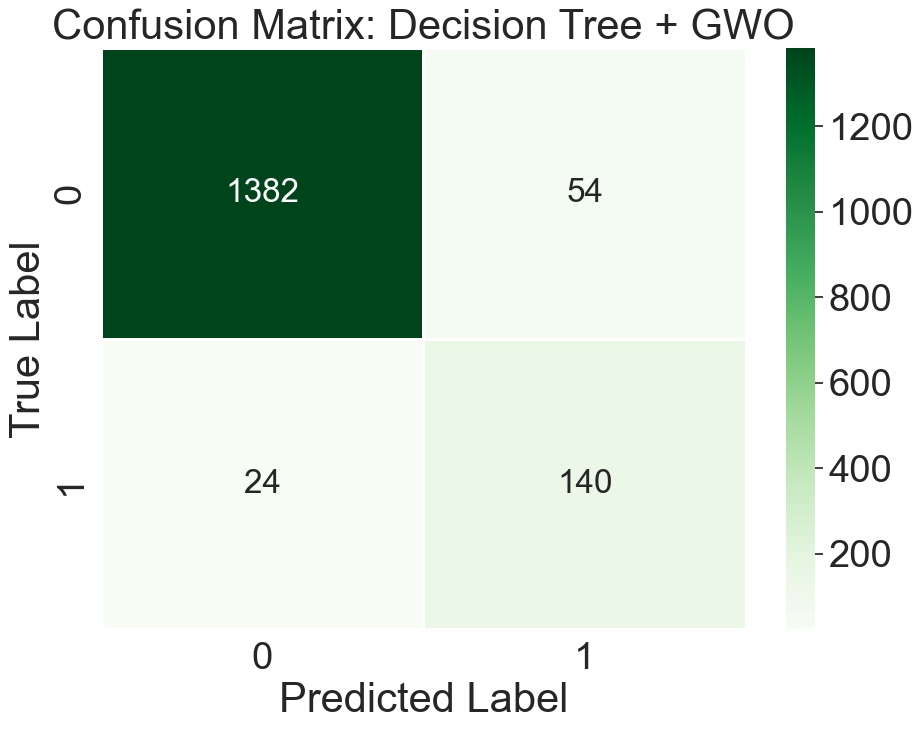


ROC AUC = 0.9080270398804265


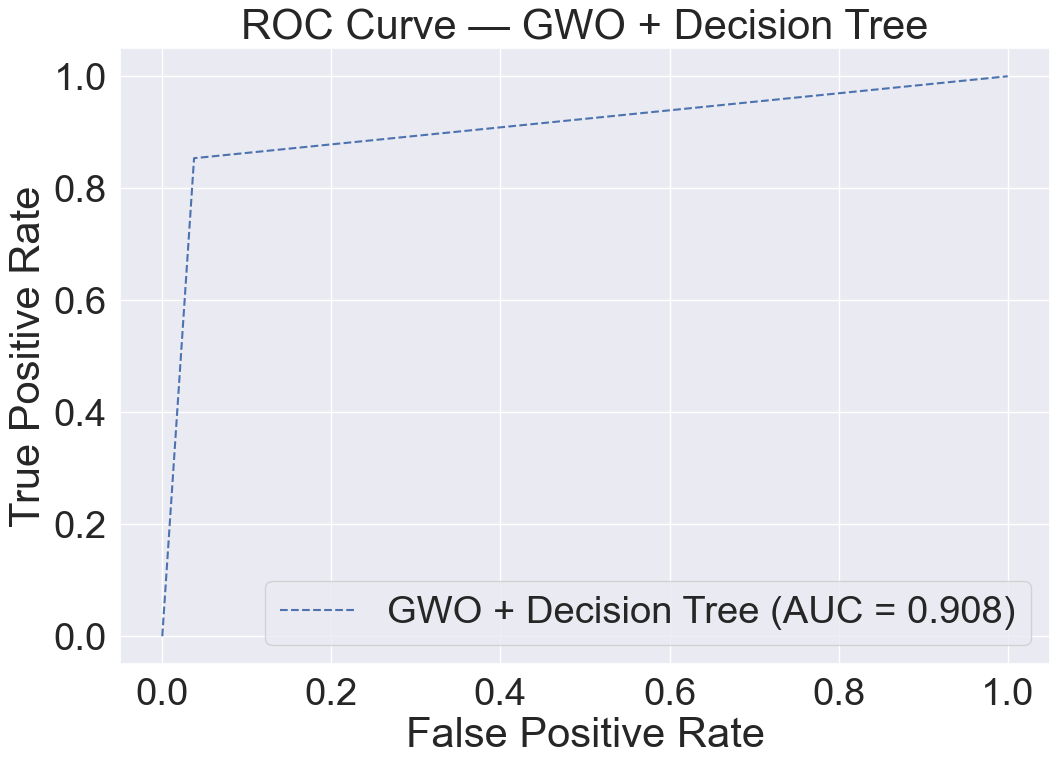

In [20]:


# ============================================================
#     FITNESS FUNCTION (Decision Tree) - Same as before
# ============================================================
def fitness_function(params, X_train, y_train, X_test, y_test):
    
    max_depth = int(params[0])
    min_samples_split = int(params[1])
    min_samples_leaf = int(params[2])
    criterion_idx = int(round(params[3]))
    
    criterion_map = {0: 'gini', 1: 'entropy', 2: 'log_loss'}
    criterion = criterion_map.get(criterion_idx, 'gini')
    
    model = DecisionTreeClassifier(
        max_depth=max_depth if max_depth > 0 else 1,
        min_samples_split=min_samples_split if min_samples_split >= 2 else 2,
        min_samples_leaf=min_samples_leaf if min_samples_leaf >= 1 else 1,
        criterion=criterion,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    return acc


# ============================================================
#     GREY WOLF OPTIMIZER (GWO) ALGORITHM
# ============================================================
def gwo_algorithm(
    X_train, y_train, X_test, y_test,
    num_wolves=10, max_iter=20
):
    
    dim = 4  # (max_depth, min_samples_split, min_samples_leaf, criterion)
    
    # Lower & upper bounds
    lb = np.array([1, 2, 1, 0])
    ub = np.array([20, 20, 10, 2])
    
    # Initialize wolves positions
    wolves = np.random.uniform(lb, ub, (num_wolves, dim))
    fitness = np.zeros(num_wolves)
    
    # Evaluate initial fitness
    for i in range(num_wolves):
        fitness[i] = fitness_function(wolves[i], X_train, y_train, X_test, y_test)
    
    # Find Alpha, Beta, Delta wolves (best, second best, third best)
    sorted_indices = np.argsort(fitness)[::-1]  # descending order
    alpha_pos = wolves[sorted_indices[0]].copy()
    alpha_score = fitness[sorted_indices[0]]
    beta_pos = wolves[sorted_indices[1]].copy()
    beta_score = fitness[sorted_indices[1]]
    delta_pos = wolves[sorted_indices[2]].copy()
    delta_score = fitness[sorted_indices[2]]
    
    print(f"Initial Best (Alpha) = {alpha_pos}, Fitness = {alpha_score:.4f}")
    
    # Main GWO loop
    for iteration in range(max_iter):
        
        # Update a (decreases linearly from 2 to 0)
        a = 2 - iteration * (2 / max_iter)
        
        for i in range(num_wolves):
            for j in range(dim):
                # Update for Alpha
                r1 = np.random.random()
                r2 = np.random.random()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = abs(C1 * alpha_pos[j] - wolves[i][j])
                X1 = alpha_pos[j] - A1 * D_alpha
                
                # Update for Beta
                r1 = np.random.random()
                r2 = np.random.random()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = abs(C2 * beta_pos[j] - wolves[i][j])
                X2 = beta_pos[j] - A2 * D_beta
                
                # Update for Delta
                r1 = np.random.random()
                r2 = np.random.random()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = abs(C3 * delta_pos[j] - wolves[i][j])
                X3 = delta_pos[j] - A3 * D_delta
                
                # New position (average of Alpha, Beta, Delta)
                wolves[i][j] = (X1 + X2 + X3) / 3
            
            # Clip to bounds
            wolves[i] = np.clip(wolves[i], lb, ub)
            
            # Evaluate new fitness
            new_fitness = fitness_function(wolves[i], X_train, y_train, X_test, y_test)
            
            # Update if better
            if new_fitness > fitness[i]:
                fitness[i] = new_fitness
                
                # Update Alpha, Beta, Delta
                if new_fitness > alpha_score:
                    alpha_score = new_fitness
                    alpha_pos = wolves[i].copy()
                elif new_fitness > beta_score:
                    beta_score = new_fitness
                    beta_pos = wolves[i].copy()
                elif new_fitness > delta_score:
                    delta_score = new_fitness
                    delta_pos = wolves[i].copy()
        
        print(f"Iteration {iteration+1}/{max_iter} — Best Fitness (Alpha) = {alpha_score:.4f}")
    
    return alpha_pos, alpha_score


# ============================================================
#        RUN GWO OPTIMIZATION
# ============================================================
best_params, best_score = gwo_algorithm(
    X_train, y_train, X_test, y_test,
    num_wolves=10,     # Can adjust (10-15 recommended)
    max_iter=10        # Can adjust (20-50 recommended)
)

best_max_depth = int(best_params[0])
best_min_samples_split = int(best_params[1])
best_min_samples_leaf = int(best_params[2])
best_criterion_idx = int(round(best_params[3]))

criterion_map = {0: 'gini', 1: 'entropy', 2: 'log_loss'}
best_criterion = criterion_map.get(best_criterion_idx, 'gini')

print("\n==============================")
print(" BEST PARAMETERS (GWO)")
print("==============================")
print("max_depth =", best_max_depth)
print("min_samples_split =", best_min_samples_split)
print("min_samples_leaf =", best_min_samples_leaf)
print("criterion =", best_criterion)
print("Best Accuracy =", best_score)


# ============================================================
#      TRAIN FINAL MODEL WITH TIME MEASUREMENT
# ============================================================
model = DecisionTreeClassifier(
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    criterion=best_criterion,
    random_state=42
)

# Training time
train_start = time.time()
model.fit(X_train, y_train)
train_end = time.time()
training_time = train_end - train_start
print(f"\nTraining Time: {training_time:.4f} seconds")

# Testing time
test_start = time.time()
predictions = model.predict(X_test)
test_end = time.time()
testing_time = test_end - test_start
print(f"Testing Time: {testing_time:.4f} seconds")

# Total time
total_time = training_time + testing_time
print(f"Total Execution Time (Train + Test): {total_time:.4f} seconds\n")

# Train accuracy
train_accuracy = accuracy_score(y_train, model.predict(X_train))
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {best_score:.4f}\n")


# ============================================================
#                PERFORMANCE METRICS
# ============================================================
accuracy_dt_gwo = accuracy_score(y_test, predictions)
precision_dt_gwo = precision_score(y_test, predictions, average='macro')
recall_dt_gwo = recall_score(y_test, predictions, average='macro')
f1_dt_gwo = f1_score(y_test, predictions, average='macro')
mcc_dt_gwo = matthews_corrcoef(y_test, predictions)

print("\n===== FINAL MODEL PERFORMANCE (GWO) =====")
print("Accuracy:", accuracy_dt_gwo)
print("Precision:", precision_dt_gwo)
print("Recall:", recall_dt_gwo)
print("F1 Score:", f1_dt_gwo)
print("MCC:", mcc_dt_gwo)


# ============================================================
#                CLASSIFICATION REPORT
# ============================================================
print("\n===== CLASSIFICATION REPORT =====")
report = classification_report(y_test, predictions)
print(report)


# ============================================================
#                      CONFUSION MATRIX
# ============================================================
conf_matrix = confusion_matrix(y_test, predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

if conf_matrix.shape == (2, 2):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]
    print("TP =", TP)
    print("FP =", FP)
    print("FN =", FN)
    print("TN =", TN)
else:
    print("Multi-class confusion matrix detected")
    for i in range(conf_matrix.shape[0]):
        print(f"Class {i}: {conf_matrix[i]}")

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt=".0f", cmap="Greens",
            annot_kws={"size": 24}, linewidths=1)
plt.title("Confusion Matrix: Decision Tree + GWO")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# ============================================================
#                        ROC CURVE + AUC
# ============================================================
if len(np.unique(y_test)) == 2:
    auc_score = roc_auc_score(y_test, predictions)
    print("\nROC AUC =", auc_score)
    
    fpr, tpr, _ = roc_curve(y_test, predictions)
    
    plt.figure(figsize=(12, 8))
    plt.plot(fpr, tpr, linestyle='--',
             label=f"GWO + Decision Tree (AUC = {auc_score:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — GWO + Decision Tree")
    plt.legend()
    plt.show()
else:
    print("\nROC Curve not available for multi-class classification")

Initial Best (Best Tuna) = [13.51699509 16.32786794  6.48772767  1.45359291], Fitness = 0.9456
Iteration 1/10 — Best Fitness = 0.9481
Iteration 2/10 — Best Fitness = 0.9487
Iteration 3/10 — Best Fitness = 0.9487
Iteration 4/10 — Best Fitness = 0.9487
Iteration 5/10 — Best Fitness = 0.9487
Iteration 6/10 — Best Fitness = 0.9487
Iteration 7/10 — Best Fitness = 0.9487
Iteration 8/10 — Best Fitness = 0.9487
Iteration 9/10 — Best Fitness = 0.9487
Iteration 10/10 — Best Fitness = 0.9487

 BEST PARAMETERS (TSO)
max_depth = 19
min_samples_split = 19
min_samples_leaf = 5
criterion = entropy
Best Accuracy = 0.94875

Training Time: 0.1734 seconds
Testing Time: 0.0010 seconds
Total Execution Time (Train + Test): 0.1744 seconds

Training Accuracy: 0.9812
Testing Accuracy: 0.9487


===== FINAL MODEL PERFORMANCE (TSO) =====
Accuracy: 0.94875
Precision: 0.8429687061070846
Recall: 0.9147360554385489
F1 Score: 0.8741095553917957
MCC: 0.7542983184648239

===== CLASSIFICATION REPORT =====
              pr

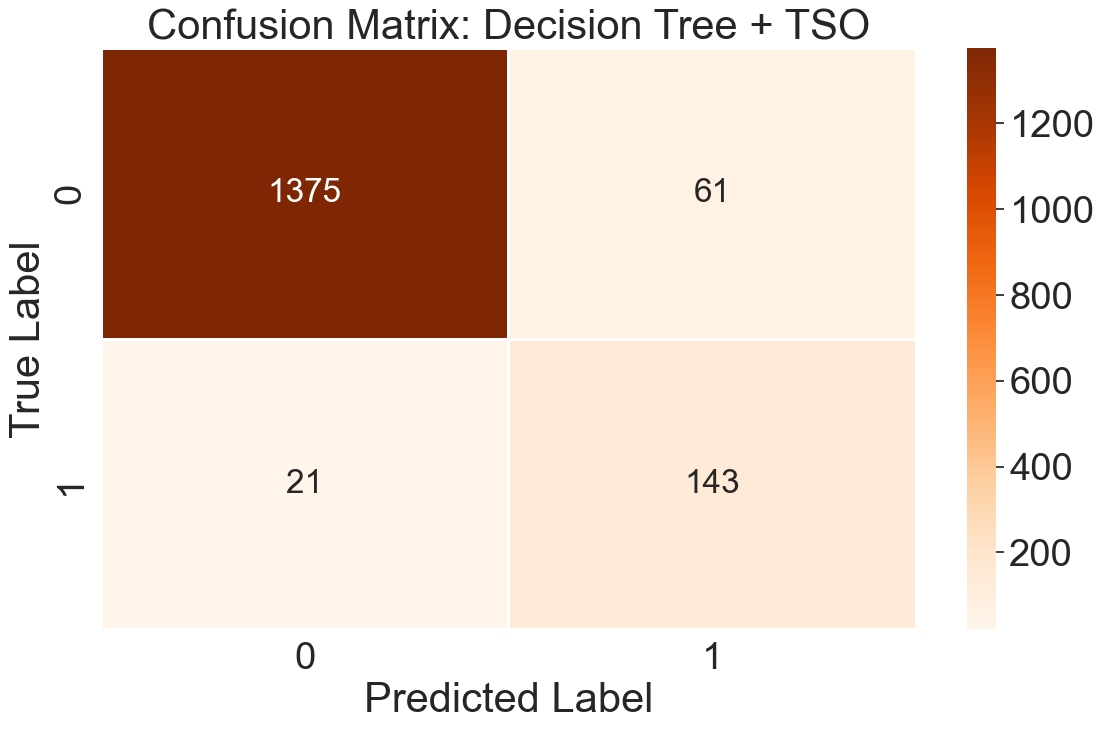


ROC AUC = 0.9147360554385489


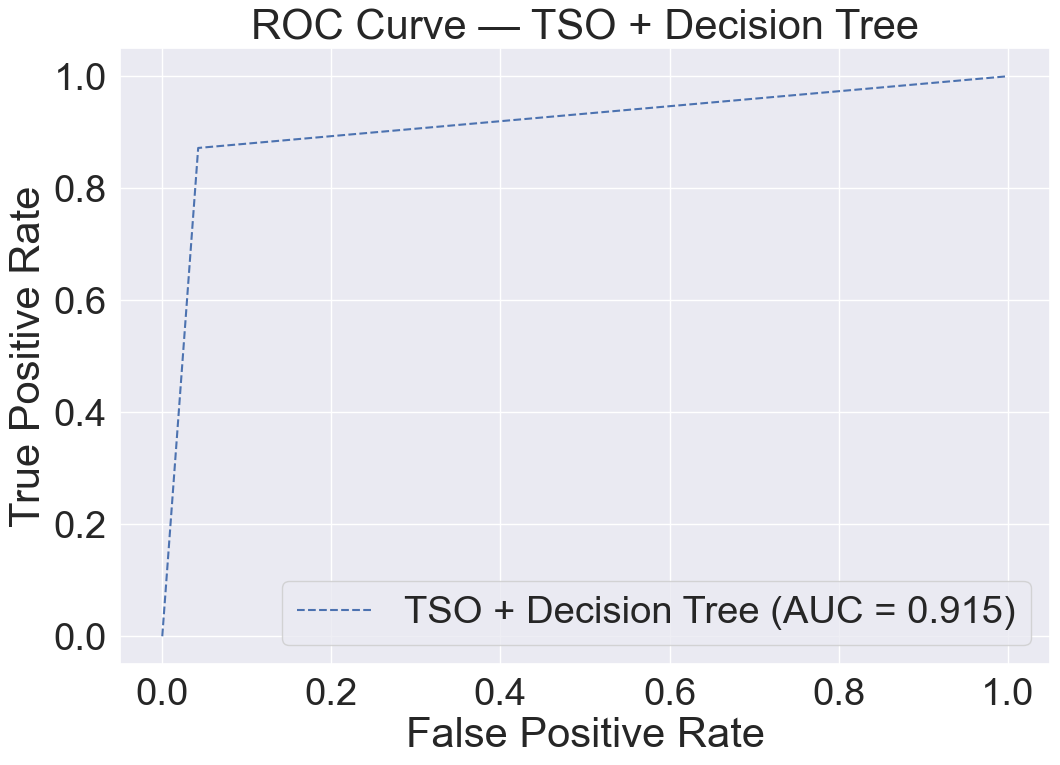

In [24]:

# ============================================================
#     FITNESS FUNCTION (Decision Tree) - Same as before
# ============================================================
def fitness_function(params, X_train, y_train, X_test, y_test):
    
    max_depth = int(params[0])
    min_samples_split = int(params[1])
    min_samples_leaf = int(params[2])
    criterion_idx = int(round(params[3]))
    
    criterion_map = {0: 'gini', 1: 'entropy', 2: 'log_loss'}
    criterion = criterion_map.get(criterion_idx, 'gini')
    
    # Ensure valid values
    max_depth = max(1, max_depth)
    min_samples_split = max(2, min_samples_split)
    min_samples_leaf = max(1, min_samples_leaf)
    
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    return acc


# ============================================================
#     TUNA SWARM OPTIMIZATION (TSO)  ALGORITHM
# ============================================================
def tso_algorithm(
    X_train, y_train, X_test, y_test,
    population_size=10, max_iter=20, z=0.05
):
    """
    Tuna Swarm Optimization Algorithm
    Parameters:
    - population_size: Number of tuna fish (parameters)
    - max_iter: Maximum number of iterations
    - z: Probability of random repositioning (value between 0 and 1, typically 0.05) [citation:8]
    """
    
    dim = 4  # (max_depth, min_samples_split, min_samples_leaf, criterion)
    
    # Lower and upper bounds
    lb = np.array([1, 2, 1, 0])
    ub = np.array([20, 20, 10, 2])
    
    # Step 1: Random initialization of tuna population [citation:4][citation:8]
    tunas = np.random.uniform(lb, ub, (population_size, dim))
    fitness = np.zeros(population_size)
    
    # Calculate initial fitness
    for i in range(population_size):
        fitness[i] = fitness_function(tunas[i], X_train, y_train, X_test, y_test)
    
    # Best global position (best food)
    best_idx = np.argmax(fitness)
    best_tuna = tunas[best_idx].copy()
    best_fitness = fitness[best_idx]
    
    print(f"Initial Best (Best Tuna) = {best_tuna}, Fitness = {best_fitness:.4f}")
    
    # ============================================================
    # Main loop of TSO algorithm
    # ============================================================
    for iteration in range(max_iter):
        
        # Update parameters a1, a2, p (used in search formulas) [citation:2][citation:6]
        a1 = 2.0 * np.exp(-((4 * iteration / max_iter) ** 2))
        a2 = 2.0 - 2.0 * (iteration / max_iter)
        p = (1 - iteration / max_iter) ** (iteration / max_iter)  # Adaptation parameter [citation:6]
        
        for i in range(population_size):
            
            # Random selection of search strategy
            rand = np.random.random()
            
            # Step 2: Random repositioning (with probability z) [citation:6][citation:8]
            if rand < z:
                # Random reinitialization within bounds
                tunas[i] = np.random.uniform(lb, ub)
                
            # Step 3: Parabolic Foraging [citation:6][citation:8]
            elif rand >= 0.5:
                # Parabolic foraging - simulates tuna hunting by jumping on prey
                TF = 1 if np.random.random() < 0.5 else -1  # Random factor -1 or 1
                
                if np.random.random() < 0.5:
                    # First parabolic foraging formula
                    new_position = (best_tuna + 
                                   np.random.random() * (best_tuna - tunas[i]) +
                                   TF * (p ** 2) * (best_tuna - tunas[i]))
                else:
                    # Second parabolic foraging formula
                    new_position = TF * (p ** 2) * best_tuna
                
                tunas[i] = np.clip(new_position, lb, ub)
                
            # Step 4: Spiral Foraging [citation:8][citation:3]
            else:
                # Spiral foraging - simulates spiral movement of tuna around prey
                
                if np.random.random() < 0.5:
                    # Spiral foraging with random reference point
                    rand_index = np.random.randint(population_size)
                    beta = np.exp(np.random.random() * 3 - 1) * np.cos(2 * np.pi * np.random.random())
                    
                    if iteration / max_iter < np.random.random():
                        # Using random position as reference
                        new_position = (tunas[rand_index] + 
                                       beta * (tunas[rand_index] - tunas[i]) +
                                       a1 * (ub - lb) * np.random.random() + 
                                       a2 * lb)
                    else:
                        # Using best position as reference
                        new_position = (best_tuna + 
                                       beta * (best_tuna - tunas[i]) +
                                       a1 * (ub - lb) * np.random.random() + 
                                       a2 * lb)
                else:
                    # Spiral foraging with a2 parameter influence
                    beta = np.exp(np.random.random() * 3 - 1) * np.cos(2 * np.pi * np.random.random())
                    new_position = (a2 * best_tuna + 
                                   beta * (a2 * best_tuna - tunas[i]) +
                                   a1 * (ub - lb) * np.random.random())
                
                tunas[i] = np.clip(new_position, lb, ub)
        
        # Evaluate all new individuals [citation:8]
        for i in range(population_size):
            new_fitness = fitness_function(tunas[i], X_train, y_train, X_test, y_test)
            
            if new_fitness > fitness[i]:
                fitness[i] = new_fitness
            else:
                # If solution did not improve, keep the old solution
                pass
        
        # Update best position (best tuna) [citation:4][citation:8]
        current_best_idx = np.argmax(fitness)
        if fitness[current_best_idx] > best_fitness:
            best_fitness = fitness[current_best_idx]
            best_tuna = tunas[current_best_idx].copy()
        
        print(f"Iteration {iteration+1}/{max_iter} — Best Fitness = {best_fitness:.4f}")
    
    return best_tuna, best_fitness


# ============================================================
#        RUN TSO OPTIMIZATION
# ============================================================
best_params, best_score = tso_algorithm(
    X_train, y_train, X_test, y_test,
    population_size=20,    # Number of tuna fish (10-15 suitable) [citation:8]
    max_iter=10,           # Number of iterations (20-50 suitable)
    z=0.05                 # Random repositioning probability [citation:8]
)

best_max_depth = int(best_params[0])
best_min_samples_split = int(best_params[1])
best_min_samples_leaf = int(best_params[2])
best_criterion_idx = int(round(best_params[3]))

criterion_map = {0: 'gini', 1: 'entropy', 2: 'log_loss'}
best_criterion = criterion_map.get(best_criterion_idx, 'gini')

print("\n==============================")
print(" BEST PARAMETERS (TSO)")
print("==============================")
print("max_depth =", best_max_depth)
print("min_samples_split =", best_min_samples_split)
print("min_samples_leaf =", best_min_samples_leaf)
print("criterion =", best_criterion)
print("Best Accuracy =", best_score)


# ============================================================
#      TRAIN FINAL MODEL WITH TIME MEASUREMENT
# ============================================================
model = DecisionTreeClassifier(
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    criterion=best_criterion,
    random_state=42
)

# Training time
train_start = time.time()
model.fit(X_train, y_train)
train_end = time.time()
training_time = train_end - train_start
print(f"\nTraining Time: {training_time:.4f} seconds")

# Testing time
test_start = time.time()
predictions = model.predict(X_test)
test_end = time.time()
testing_time = test_end - test_start
print(f"Testing Time: {testing_time:.4f} seconds")

# Total time
total_time = training_time + testing_time
print(f"Total Execution Time (Train + Test): {total_time:.4f} seconds\n")

# Training accuracy
train_accuracy = accuracy_score(y_train, model.predict(X_train))
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {best_score:.4f}\n")


# ============================================================
#                PERFORMANCE METRICS
# ============================================================
accuracy_dt_tso = accuracy_score(y_test, predictions)
precision_dt_tso = precision_score(y_test, predictions, average='macro')
recall_dt_tso = recall_score(y_test, predictions, average='macro')
f1_dt_tso = f1_score(y_test, predictions, average='macro')
mcc_dt_tso = matthews_corrcoef(y_test, predictions)

print("\n===== FINAL MODEL PERFORMANCE (TSO) =====")
print("Accuracy:", accuracy_dt_tso)
print("Precision:", precision_dt_tso)
print("Recall:", recall_dt_tso)
print("F1 Score:", f1_dt_tso)
print("MCC:", mcc_dt_tso)


# ============================================================
#                CLASSIFICATION REPORT
# ============================================================
print("\n===== CLASSIFICATION REPORT =====")
report = classification_report(y_test, predictions)
print(report)


# ============================================================
#                      CONFUSION MATRIX
# ============================================================
conf_matrix = confusion_matrix(y_test, predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

if conf_matrix.shape == (2, 2):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]
    print("TP =", TP)
    print("FP =", FP)
    print("FN =", FN)
    print("TN =", TN)
else:
    print("Multi-class confusion matrix detected")
    for i in range(conf_matrix.shape[0]):
        print(f"Class {i}: {conf_matrix[i]}")

plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt=".0f", cmap="Oranges",
            annot_kws={"size": 24}, linewidths=1)
plt.title("Confusion Matrix: Decision Tree + TSO")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


# ============================================================
#                        ROC CURVE + AUC
# ============================================================
if len(np.unique(y_test)) == 2:
    auc_score = roc_auc_score(y_test, predictions)
    print("\nROC AUC =", auc_score)
    
    fpr, tpr, _ = roc_curve(y_test, predictions)
    
    plt.figure(figsize=(12, 8))
    plt.plot(fpr, tpr, linestyle='--',
             label=f"TSO + Decision Tree (AUC = {auc_score:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — TSO + Decision Tree")
    plt.legend()
    plt.show()
else:
    print("\nROC Curve not available for multi-class classification")

In [ ]:
'''
plt.figure(figsize=(14, 12))

# LDA
plt.plot(lda_fpr, lda_tpr, linestyle='--', label='LDA (ROC = %0.4f)' % lda_auc)

# Random Forest
plt.plot(rf_fpr, rf_tpr, linestyle='--', label='RF (ROC = %0.4f)' % rf_auc)

# Naive Bayes
plt.plot(nb_fpr, nb_tpr, linestyle='--', label='NB (ROC = %0.4f)' % nb_auc)

# SVM
plt.plot(svm_fpr, svm_tpr, linestyle='--', label='SVM (ROC = %0.4f)' % svm_auc)

# SVM
plt.plot(bag_fpr, bag_tpr, linestyle='--', label='BAG (ROC = %0.4f)' % bag_auc)

# ABC + Bagging
plt.plot(fpr, tpr, linestyle='--', label='ABC + BAG (ROC = %0.4f)' % auc_score)

# Final plot settings
plt.title('ROC Curves Comparison for All Models', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()
'''

In [ ]:
'''
accuracy_lda, precision_lda, recall_lda, f1_lda, mcc_lda
accuracy_rf, precision_rf, recall_rf, f1_rf, mcc_rf
accuracy_nb, precision_nb, recall_nb, f1_nb, mcc_nb
accuracy_svm, precision_svm, recall_svm, f1_svm, mcc_svm
accuracy_bag, precision_bag, recall_bag, f1_bag, mcc_bag
accuracy_bag, precision_bag, recall_bag, f1_bag, mcc_bag


# Create a dictionary with all metrics
data = {
    'Model': ['LDA', 'RF', ' NB', 'SVM','BAG', 'ABC + BAG'],
    'Accuracy': [accuracy_lda, accuracy_rf, accuracy_nb, accuracy_svm, accuracy_bag,accuracy_abc],
    'Precision': [precision_lda, precision_rf, precision_nb, precision_svm,precision_bag, precision_abc],
    'Recall': [recall_lda, recall_rf, recall_nb, recall_svm,recall_bag, recall_abc],
    'F1 Score': [f1_lda, f1_rf, f1_nb, f1_svm,recall_bag ,f1_abc],
    'MCC': [mcc_lda, mcc_rf, mcc_nb, mcc_svm,recall_bag , mcc_abc]
}

# Convert dictionary to DataFrame
results_df = pd.DataFrame(data)

# Display table
results_df
'''

In [ ]:
'''
# Metrics and models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'MCC']
models = ['LDA', 'RF', 'NB', 'SVM','BAG', 'ABC + BAG']

# Values for each model
values = results_df[metrics].values  

# Plotting
x = np.arange(len(metrics))  
width = 0.15  

plt.figure(figsize=(25, 10))

# Plot each model's bars
for i in range(len(models)):
    plt.bar(x + i*width, values[i], width=width, label=models[i])

# Labels and formatting
plt.xticks(x + width*2, metrics, fontsize=20)  
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.title('Comparison of Performance Metrics Across Models', fontsize=16)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
'''

# Good Luck

In [2]:
import tkinter as tk
from tkinter import ttk, messagebox, scrolledtext
import pandas as pd
import numpy as np
import joblib
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.figure import Figure
import warnings
warnings.filterwarnings('ignore')

class WaterQualityApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Water Quality Prediction System - GWO Optimized")
        self.root.geometry("1400x900")
        self.root.configure(bg='#f0f0f0')
        
        # Load the trained model
        self.load_model()
        
        # Danger thresholds (for reference)
        self.THRESHOLDS = {
            'aluminium': 2.8, 'ammonia': 32.5, 'arsenic': 0.01,
            'barium': 2.0, 'cadmium': 0.005, 'chloramine': 4.0,
            'chromium': 0.1, 'copper': 1.3, 'flouride': 1.5,
            'bacteria': 0.0, 'viruses': 0.0, 'lead': 0.015,
            'nitrates': 10.0, 'nitrites': 1.0, 'mercury': 0.002,
            'perchlorate': 56.0, 'radium': 5.0, 'selenium': 0.5,
            'silver': 0.1, 'uranium': 0.3
        }
        
        # Feature order (must match training data)
        self.FEATURES = [
            'aluminium', 'ammonia', 'arsenic', 'barium', 'cadmium',
            'chloramine', 'chromium', 'copper', 'flouride', 'bacteria',
            'viruses', 'lead', 'nitrates', 'nitrites', 'mercury',
            'perchlorate', 'radium', 'selenium', 'silver', 'uranium'
        ]
        
        # Dictionary to store input variables
        self.input_vars = {}
        
        # Setup GUI
        self.setup_gui()
        
    def load_model(self):
        """Load the trained model from pickle file"""
        try:
            self.model = joblib.load('water_quality_model.pkl')
            print("✅ Model loaded successfully!")
        except FileNotFoundError:
            messagebox.showerror("Error", 
                "Model file 'water_quality_model.pkl' not found!\n"
                "Please make sure the file is in the same directory.")
            self.model = None
        except Exception as e:
            messagebox.showerror("Error", f"Error loading model: {str(e)}")
            self.model = None
    
    def setup_gui(self):
        """Setup the main GUI interface"""
        
        # Title Frame
        title_frame = tk.Frame(self.root, bg='#2c3e50', height=80)
        title_frame.pack(fill='x')
        title_frame.pack_propagate(False)
        
        title_label = tk.Label(title_frame, 
                               text="💧 Water Quality Prediction System", 
                               font=("Arial", 24, "bold"),
                               fg='white', bg='#2c3e50')
        title_label.pack(pady=20)
        
        subtitle_label = tk.Label(title_frame,
                                 text="Grey Wolf Optimizer + Decision Tree Model",
                                 font=("Arial", 10),
                                 fg='#ecf0f1', bg='#2c3e50')
        subtitle_label.pack()
        
        # Main content frame with scrollbar
        main_frame = tk.Frame(self.root, bg='#f0f0f0')
        main_frame.pack(fill='both', expand=True, padx=10, pady=10)
        
        # Create canvas for scrolling
        canvas = tk.Canvas(main_frame, bg='#f0f0f0')
        scrollbar = tk.Scrollbar(main_frame, orient="vertical", command=canvas.yview)
        self.scrollable_frame = tk.Frame(canvas, bg='#f0f0f0')
        
        self.scrollable_frame.bind(
            "<Configure>",
            lambda e: canvas.configure(scrollregion=canvas.bbox("all"))
        )
        
        canvas.create_window((0, 0), window=self.scrollable_frame, anchor="nw")
        canvas.configure(yscrollcommand=scrollbar.set)
        
        canvas.pack(side="left", fill="both", expand=True)
        scrollbar.pack(side="right", fill="y")
        
        # Create notebook for tabs
        self.notebook = ttk.Notebook(self.scrollable_frame)
        self.notebook.pack(fill='both', expand=True, padx=10, pady=10)
        
        # Create tabs
        self.create_input_tab()
        self.create_visualization_tab()
        self.create_results_tab()
        self.create_info_tab()
        
        # Bottom frame for predict button
        bottom_frame = tk.Frame(self.root, bg='#f0f0f0', height=80)
        bottom_frame.pack(fill='x', side='bottom')
        bottom_frame.pack_propagate(False)
        
        predict_button = tk.Button(bottom_frame, 
                                  text="🔍 PREDICT WATER QUALITY", 
                                  command=self.predict,
                                  font=("Arial", 14, "bold"),
                                  bg='#27ae60', fg='white',
                                  padx=30, pady=15,
                                  relief='raised', bd=3)
        predict_button.pack(pady=15)
        
        # Status bar
        self.status_bar = tk.Label(self.root, text="Ready", bd=1, relief=tk.SUNKEN, 
                                   anchor=tk.W, bg='#ecf0f1', fg='#2c3e50')
        self.status_bar.pack(side=tk.BOTTOM, fill=tk.X)
    
    def create_input_tab(self):
        """Create input tab with all parameters - LEFT ALIGNED"""
        input_tab = ttk.Frame(self.notebook)
        self.notebook.add(input_tab, text="📝 Input Parameters")
        
        # Create canvas for scrolling within input tab
        input_canvas = tk.Canvas(input_tab, bg='#f0f0f0')
        input_scrollbar = tk.Scrollbar(input_tab, orient="vertical", command=input_canvas.yview)
        input_scrollable = tk.Frame(input_canvas, bg='#f0f0f0')
        
        input_scrollable.bind(
            "<Configure>",
            lambda e: input_canvas.configure(scrollregion=input_canvas.bbox("all"))
        )
        
        input_canvas.create_window((0, 0), window=input_scrollable, anchor="nw")
        input_canvas.configure(yscrollcommand=input_scrollbar.set)
        
        input_canvas.pack(side="left", fill="both", expand=True)
        input_scrollbar.pack(side="right", fill="y")
        
        # Create frames for different categories - LEFT ALIGNED
        chem_frame = tk.LabelFrame(input_scrollable, text="Chemical Parameters", 
                                  font=("Arial", 12, "bold"), bg='#f0f0f0', padx=10, pady=10)
        chem_frame.pack(fill='x', padx=10, pady=5, anchor='w')  # Added anchor='w'
        
        heavy_frame = tk.LabelFrame(input_scrollable, text="Heavy Metals", 
                                   font=("Arial", 12, "bold"), bg='#f0f0f0', padx=10, pady=10)
        heavy_frame.pack(fill='x', padx=10, pady=5, anchor='w')  # Added anchor='w'
        
        bio_frame = tk.LabelFrame(input_scrollable, text="Biological Contaminants", 
                                 font=("Arial", 12, "bold"), bg='#f0f0f0', padx=10, pady=10)
        bio_frame.pack(fill='x', padx=10, pady=5, anchor='w')  # Added anchor='w'
        
        # Chemical Parameters - LEFT ALIGNED
        chem_params = ['aluminium', 'ammonia', 'arsenic', 'barium', 'cadmium', 
                      'chloramine', 'chromium', 'copper', 'flouride', 
                      'nitrates', 'nitrites', 'perchlorate', 'radium']
        
        for i, param in enumerate(chem_params):
            row = i // 2  # Changed from 3 to 2 columns for better visibility
            col = i % 2
            frame = tk.Frame(chem_frame, bg='#f0f0f0')
            frame.grid(row=row, column=col, padx=10, pady=8, sticky='w')  # Changed to sticky='w'
            
            label = tk.Label(frame, text=f"{param.title()}:", 
                           font=("Arial", 10), bg='#f0f0f0', width=15, anchor='w')
            label.pack(side='left')
            
            var = tk.DoubleVar(value=0.0)
            self.input_vars[param] = var
            
            entry = tk.Entry(frame, textvariable=var, width=15, font=("Arial", 10))
            entry.pack(side='left', padx=5)
            
            threshold_label = tk.Label(frame, text=f"(max: {self.THRESHOLDS[param]})", 
                                      font=("Arial", 8), fg='gray', bg='#f0f0f0')
            threshold_label.pack(side='left', padx=5)
        
        # Heavy Metals - LEFT ALIGNED
        heavy_params = ['lead', 'mercury', 'selenium', 'silver', 'uranium']
        
        for i, param in enumerate(heavy_params):
            frame = tk.Frame(heavy_frame, bg='#f0f0f0')
            frame.grid(row=i, column=0, padx=10, pady=8, sticky='w')  # Changed to sticky='w'
            
            label = tk.Label(frame, text=f"{param.title()}:", 
                           font=("Arial", 10), bg='#f0f0f0', width=15, anchor='w')
            label.pack(side='left')
            
            var = tk.DoubleVar(value=0.0)
            self.input_vars[param] = var
            
            entry = tk.Entry(frame, textvariable=var, width=15, font=("Arial", 10))
            entry.pack(side='left', padx=5)
            
            threshold_label = tk.Label(frame, text=f"(max: {self.THRESHOLDS[param]})", 
                                      font=("Arial", 8), fg='gray', bg='#f0f0f0')
            threshold_label.pack(side='left', padx=5)
        
        # Biological Contaminants - LEFT ALIGNED
        bio_params = ['bacteria', 'viruses']
        
        for i, param in enumerate(bio_params):
            frame = tk.Frame(bio_frame, bg='#f0f0f0')
            frame.grid(row=i, column=0, padx=10, pady=8, sticky='w')  # Changed to sticky='w'
            
            label = tk.Label(frame, text=f"{param.title()}:", 
                           font=("Arial", 10), bg='#f0f0f0', width=15, anchor='w')
            label.pack(side='left')
            
            var = tk.DoubleVar(value=0.0)
            self.input_vars[param] = var
            
            entry = tk.Entry(frame, textvariable=var, width=15, font=("Arial", 10))
            entry.pack(side='left', padx=5)
            
            threshold_label = tk.Label(frame, text=f"(max: {self.THRESHOLDS[param]})", 
                                      font=("Arial", 8), fg='gray', bg='#f0f0f0')
            threshold_label.pack(side='left', padx=5)
    
    def create_visualization_tab(self):
        """Create visualization tab for charts"""
        vis_tab = ttk.Frame(self.notebook)
        self.notebook.add(vis_tab, text="📊 Visualizations")
        
        # Create matplotlib figure
        self.fig = Figure(figsize=(10, 8), dpi=100)
        self.canvas = FigureCanvasTkAgg(self.fig, master=vis_tab)
        self.canvas.get_tk_widget().pack(fill='both', expand=True, padx=10, pady=10)
    
    def create_results_tab(self):
        """Create results tab - LEFT ALIGNED TEXT"""
        results_tab = ttk.Frame(self.notebook)
        self.notebook.add(results_tab, text="📈 Results")
        
        # Create a frame for better organization
        results_frame = tk.Frame(results_tab, bg='#f0f0f0')
        results_frame.pack(fill='both', expand=True, padx=10, pady=10)
        
        # Results display area with LEFT alignment
        self.results_text = scrolledtext.ScrolledText(results_frame, 
                                                      wrap=tk.WORD, 
                                                      width=80, 
                                                      height=25,
                                                      font=("Courier", 10),
                                                      bg='white',
                                                      fg='black')
        self.results_text.pack(fill='both', expand=True)
        
        # Configure text alignment to LEFT
        self.results_text.tag_configure('center', justify='left')
        self.results_text.tag_configure('safe', foreground='green', font=("Arial", 12, "bold"))
        self.results_text.tag_configure('danger', foreground='red', font=("Arial", 12, "bold"))
        self.results_text.tag_configure('warning', foreground='orange', font=("Arial", 10, "bold"))
        self.results_text.tag_configure('header', foreground='blue', font=("Arial", 11, "bold"))
        
        # Add export button
        export_button = tk.Button(results_frame, 
                                 text="📥 Export Results", 
                                 command=self.export_results,
                                 font=("Arial", 10),
                                 bg='#3498db', fg='white',
                                 padx=10, pady=5)
        export_button.pack(pady=5)
    
    def create_info_tab(self):
        """Create information tab - LEFT ALIGNED TEXT"""
        info_tab = ttk.Frame(self.notebook)
        self.notebook.add(info_tab, text="ℹ️ Information")
        
        # Information display with LEFT alignment
        info_text = scrolledtext.ScrolledText(info_tab, 
                                             wrap=tk.WORD, 
                                             width=80, 
                                             height=30,
                                             font=("Arial", 10),
                                             bg='white',
                                             fg='black')
        info_text.pack(fill='both', expand=True, padx=10, pady=10)
        
        info_content = """
============================================================
WATER QUALITY PREDICTION SYSTEM
============================================================

Model Information:
-----------------
• Algorithm: Decision Tree Classifier
• Optimization: Grey Wolf Optimizer (GWO)
• Features: 20 water quality parameters
• Purpose: Predict if water is safe for consumption

Danger Thresholds:
-----------------
• Aluminium: > 2.8 mg/L
• Ammonia: > 32.5 mg/L
• Arsenic: > 0.01 mg/L
• Barium: > 2.0 mg/L
• Cadmium: > 0.005 mg/L
• Chloramine: > 4.0 mg/L
• Chromium: > 0.1 mg/L
• Copper: > 1.3 mg/L
• Fluoride: > 1.5 mg/L
• Bacteria: > 0 CFU/mL
• Viruses: > 0 PFU/mL
• Lead: > 0.015 mg/L
• Nitrates: > 10 mg/L
• Nitrites: > 1 mg/L
• Mercury: > 0.002 mg/L
• Perchlorate: > 56 mg/L
• Radium: > 5 mg/L
• Selenium: > 0.5 mg/L
• Silver: > 0.1 mg/L
• Uranium: > 0.3 mg/L

How to Use:
----------
1. Enter all water quality parameters in the Input Parameters tab
2. Click "PREDICT WATER QUALITY" button
3. View results in the Results tab
4. Check visualizations in the Visualizations tab

Note: This system is for educational purposes only.
Always consult certified laboratories for official testing.

============================================================
"""
        
        info_text.insert('1.0', info_content)
        info_text.configure(state='disabled')
    
    def predict(self):
        """Make prediction using the loaded model"""
        if self.model is None:
            messagebox.showerror("Error", "Model not loaded!")
            return
        
        try:
            # Collect input values
            input_values = []
            for feature in self.FEATURES:
                value = self.input_vars[feature].get()
                input_values.append(value)
            
            # Convert to numpy array
            input_array = np.array(input_values).reshape(1, -1)
            
            # Make prediction
            prediction = self.model.predict(input_array)[0]
            
            # Get probabilities
            try:
                probabilities = self.model.predict_proba(input_array)[0]
            except:
                probabilities = [1.0, 0.0] if prediction == 1 else [0.0, 1.0]
            
            # Store current results for export
            self.current_prediction = prediction
            self.current_probabilities = probabilities
            self.current_input_values = input_values
            
            # Update status bar
            self.status_bar.config(text="Prediction completed successfully!")
            
            # Display results
            self.display_results(prediction, probabilities, input_values)
            
            # Update visualizations
            self.update_visualizations(input_values)
            
            # Switch to results tab
            self.notebook.select(2)  # Results tab index
            
        except Exception as e:
            messagebox.showerror("Error", f"Prediction error: {str(e)}")
            self.status_bar.config(text=f"Error: {str(e)}")
    
    def display_results(self, prediction, probabilities, input_values):
        """Display prediction results with LEFT alignment"""
        self.results_text.delete('1.0', tk.END)
        
        # Header
        self.results_text.insert(tk.END, "="*60 + "\n", 'header')
        self.results_text.insert(tk.END, "WATER QUALITY PREDICTION RESULTS\n", 'header')
        self.results_text.insert(tk.END, "="*60 + "\n\n", 'header')
        
        # Prediction result
        if prediction == 1:
            self.results_text.insert(tk.END, "✅ STATUS: SAFE WATER\n\n", 'safe')
        else:
            self.results_text.insert(tk.END, "❌ STATUS: NOT SAFE - UNSAFE FOR CONSUMPTION\n\n", 'danger')
        
        # Confidence
        confidence = probabilities[prediction] * 100
        self.results_text.insert(tk.END, f"Confidence Level: {confidence:.2f}%\n")
        self.results_text.insert(tk.END, f"Safe Probability: {probabilities[1]*100:.2f}%\n")
        self.results_text.insert(tk.END, f"Unsafe Probability: {probabilities[0]*100:.2f}%\n\n")
        
        # Parameter Analysis
        self.results_text.insert(tk.END, "-"*60 + "\n", 'header')
        self.results_text.insert(tk.END, "PARAMETER ANALYSIS\n", 'header')
        self.results_text.insert(tk.END, "-"*60 + "\n\n", 'header')
        
        # Check each parameter against thresholds
        warnings = []
        for i, feature in enumerate(self.FEATURES):
            value = input_values[i]
            threshold = self.THRESHOLDS.get(feature, None)
            if threshold and value > threshold:
                warnings.append(f"⚠️ {feature.title()}: {value:.4f} > {threshold} (DANGER)")
        
        if warnings:
            self.results_text.insert(tk.END, "⚠️ SAFETY VIOLATIONS DETECTED:\n\n", 'warning')
            for warning in warnings:
                self.results_text.insert(tk.END, f"  {warning}\n")
        else:
            self.results_text.insert(tk.END, "✅ All parameters are within safe limits.\n")
        
        # Detailed parameter table
        self.results_text.insert(tk.END, "\n" + "-"*60 + "\n", 'header')
        self.results_text.insert(tk.END, "DETAILED PARAMETER TABLE\n", 'header')
        self.results_text.insert(tk.END, "-"*60 + "\n\n", 'header')
        
        # Table header
        self.results_text.insert(tk.END, f"{'Parameter':<20} {'Value':<12} {'Threshold':<12} {'Status':<10}\n", 'header')
        self.results_text.insert(tk.END, "-"*60 + "\n", 'header')
        
        # Table rows
        for feature in self.FEATURES:
            value = input_values[self.FEATURES.index(feature)]
            threshold = self.THRESHOLDS.get(feature, 0)
            status = "🔴 DANGER" if value > threshold else "🟢 SAFE"
            self.results_text.insert(tk.END, f"{feature.title():<20} {value:<12.4f} {threshold:<12} {status:<10}\n")
        
        # Footer
        self.results_text.insert(tk.END, "\n" + "="*60 + "\n", 'header')
        self.results_text.insert(tk.END, f"Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n", 'header')
        self.results_text.insert(tk.END, "="*60 + "\n", 'header')
    
    def export_results(self):
        """Export results to text file"""
        if hasattr(self, 'current_prediction'):
            filename = f"water_quality_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
            with open(filename, 'w', encoding='utf-8') as f:
                f.write(self.results_text.get('1.0', tk.END))
            messagebox.showinfo("Export Successful", f"Results exported to:\n{filename}")
        else:
            messagebox.showwarning("No Results", "Please make a prediction first!")
    
    def update_visualizations(self, input_values):
        """Update the visualization charts"""
        self.fig.clear()
        
        # Create subplots
        ax1 = self.fig.add_subplot(211)
        ax2 = self.fig.add_subplot(212)
        
        # Plot 1: Parameters vs Thresholds
        parameters = self.FEATURES[:10]  # First 10 parameters
        values = input_values[:10]
        thresholds = [self.THRESHOLDS[p] for p in parameters]
        
        x = range(len(parameters))
        width = 0.35
        
        ax1.bar([i - width/2 for i in x], values, width, label='Current Value', color='blue', alpha=0.7)
        ax1.bar([i + width/2 for i in x], thresholds, width, label='Danger Threshold', color='red', alpha=0.7)
        ax1.set_xlabel('Parameters')
        ax1.set_ylabel('Concentration (mg/L)')
        ax1.set_title('Water Quality Parameters vs Danger Thresholds (Part 1)')
        ax1.set_xticks(x)
        ax1.set_xticklabels(parameters, rotation=45, ha='right')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Remaining parameters
        parameters2 = self.FEATURES[10:]
        values2 = input_values[10:]
        thresholds2 = [self.THRESHOLDS[p] for p in parameters2]
        
        x2 = range(len(parameters2))
        
        ax2.bar([i - width/2 for i in x2], values2, width, label='Current Value', color='green', alpha=0.7)
        ax2.bar([i + width/2 for i in x2], thresholds2, width, label='Danger Threshold', color='red', alpha=0.7)
        ax2.set_xlabel('Parameters')
        ax2.set_ylabel('Concentration (mg/L)')
        ax2.set_title('Water Quality Parameters vs Danger Thresholds (Part 2)')
        ax2.set_xticks(x2)
        ax2.set_xticklabels(parameters2, rotation=45, ha='right')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        self.fig.tight_layout()
        self.canvas.draw()

# ============================================================
# MAIN APPLICATION
# ============================================================
if __name__ == "__main__":
    root = tk.Tk()
    app = WaterQualityApp(root)
    root.mainloop()

✅ Model loaded successfully!


In [3]:
import tkinter as tk
from tkinter import ttk, messagebox, scrolledtext
import pandas as pd
import numpy as np
import joblib
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.figure import Figure
import warnings
warnings.filterwarnings('ignore')

class WaterQualityApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Water Quality Prediction System - GWO Optimized")
        self.root.geometry("1400x900")
        self.root.configure(bg='#f0f0f0')
        
        # Center the window on screen
        self.center_window()
        
        # Load the trained model
        self.load_model()
        
        # Danger thresholds (for reference)
        self.THRESHOLDS = {
            'aluminium': 2.8, 'ammonia': 32.5, 'arsenic': 0.01,
            'barium': 2.0, 'cadmium': 0.005, 'chloramine': 4.0,
            'chromium': 0.1, 'copper': 1.3, 'flouride': 1.5,
            'bacteria': 0.0, 'viruses': 0.0, 'lead': 0.015,
            'nitrates': 10.0, 'nitrites': 1.0, 'mercury': 0.002,
            'perchlorate': 56.0, 'radium': 5.0, 'selenium': 0.5,
            'silver': 0.1, 'uranium': 0.3
        }
        
        # Feature order (must match training data)
        self.FEATURES = [
            'aluminium', 'ammonia', 'arsenic', 'barium', 'cadmium',
            'chloramine', 'chromium', 'copper', 'flouride', 'bacteria',
            'viruses', 'lead', 'nitrates', 'nitrites', 'mercury',
            'perchlorate', 'radium', 'selenium', 'silver', 'uranium'
        ]
        
        # Dictionary to store input variables
        self.input_vars = {}
        
        # Setup GUI
        self.setup_gui()
    
    def center_window(self):
        """Center the window on screen"""
        self.root.update_idletasks()
        width = 1400
        height = 900
        x = (self.root.winfo_screenwidth() // 2) - (width // 2)
        y = (self.root.winfo_screenheight() // 2) - (height // 2)
        self.root.geometry(f'{width}x{height}+{x}+{y}')
        
    def load_model(self):
        """Load the trained model from pickle file"""
        try:
            self.model = joblib.load('water_quality_model.pkl')
            print("✅ Model loaded successfully!")
        except FileNotFoundError:
            messagebox.showerror("Error", 
                "Model file 'water_quality_model.pkl' not found!\n"
                "Please make sure the file is in the same directory.")
            self.model = None
        except Exception as e:
            messagebox.showerror("Error", f"Error loading model: {str(e)}")
            self.model = None
    
    def setup_gui(self):
        """Setup the main GUI interface"""
        
        # Title Frame - Centered
        title_frame = tk.Frame(self.root, bg='#2c3e50', height=100)
        title_frame.pack(fill='x')
        title_frame.pack_propagate(False)
        
        title_label = tk.Label(title_frame, 
                               text="💧 Water Quality Prediction System", 
                               font=("Arial", 26, "bold"),
                               fg='white', bg='#2c3e50')
        title_label.pack(pady=15)
        
        subtitle_label = tk.Label(title_frame,
                                 text="Grey Wolf Optimizer + Decision Tree Model | AI-Powered Water Safety Assessment",
                                 font=("Arial", 11),
                                 fg='#ecf0f1', bg='#2c3e50')
        subtitle_label.pack()
        
        # Main content frame with scrollbar
        main_frame = tk.Frame(self.root, bg='#f0f0f0')
        main_frame.pack(fill='both', expand=True, padx=20, pady=10)
        
        # Create canvas for scrolling
        canvas = tk.Canvas(main_frame, bg='#f0f0f0')
        scrollbar = tk.Scrollbar(main_frame, orient="vertical", command=canvas.yview)
        self.scrollable_frame = tk.Frame(canvas, bg='#f0f0f0')
        
        self.scrollable_frame.bind(
            "<Configure>",
            lambda e: canvas.configure(scrollregion=canvas.bbox("all"))
        )
        
        canvas.create_window((0, 0), window=self.scrollable_frame, anchor="center")  # Changed to center
        canvas.configure(yscrollcommand=scrollbar.set)
        
        canvas.pack(side="left", fill="both", expand=True)
        scrollbar.pack(side="right", fill="y")
        
        # Create notebook for tabs
        self.notebook = ttk.Notebook(self.scrollable_frame)
        self.notebook.pack(fill='both', expand=True, padx=10, pady=10)
        
        # Create tabs
        self.create_input_tab()
        self.create_visualization_tab()
        self.create_results_tab()
        self.create_info_tab()
        
        # Bottom frame for predict button - Centered
        bottom_frame = tk.Frame(self.root, bg='#f0f0f0', height=100)
        bottom_frame.pack(fill='x', side='bottom')
        bottom_frame.pack_propagate(False)
        
        # Center the button
        button_frame = tk.Frame(bottom_frame, bg='#f0f0f0')
        button_frame.pack(expand=True)
        
        predict_button = tk.Button(button_frame, 
                                  text="🔍 PREDICT WATER QUALITY", 
                                  command=self.predict,
                                  font=("Arial", 16, "bold"),
                                  bg='#27ae60', fg='white',
                                  padx=40, pady=15,
                                  relief='raised', bd=3,
                                  cursor='hand2')
        predict_button.pack()
        
        # Status bar
        self.status_bar = tk.Label(self.root, text="✅ System Ready | Enter parameters and click Predict", 
                                   bd=1, relief=tk.SUNKEN, 
                                   anchor=tk.CENTER,  # Centered
                                   bg='#ecf0f1', fg='#2c3e50',
                                   font=("Arial", 9))
        self.status_bar.pack(side=tk.BOTTOM, fill=tk.X)
    
    def create_input_tab(self):
        """Create input tab with all parameters - Centered"""
        input_tab = ttk.Frame(self.notebook)
        self.notebook.add(input_tab, text="📝 Input Parameters")
        
        # Main container with center alignment
        main_container = tk.Frame(input_tab, bg='#f0f0f0')
        main_container.pack(expand=True, fill='both')
        
        # Center everything
        center_frame = tk.Frame(main_container, bg='#f0f0f0')
        center_frame.pack(expand=True)
        
        # Create frames for different categories
        chem_frame = tk.LabelFrame(center_frame, text="🧪 Chemical Parameters", 
                                  font=("Arial", 12, "bold"), bg='#f0f0f0', 
                                  padx=20, pady=15, fg='#2c3e50')
        chem_frame.pack(pady=10, padx=20, fill='x')
        
        heavy_frame = tk.LabelFrame(center_frame, text="⚙️ Heavy Metals", 
                                   font=("Arial", 12, "bold"), bg='#f0f0f0', 
                                   padx=20, pady=15, fg='#2c3e50')
        heavy_frame.pack(pady=10, padx=20, fill='x')
        
        bio_frame = tk.LabelFrame(center_frame, text="🦠 Biological Contaminants", 
                                 font=("Arial", 12, "bold"), bg='#f0f0f0', 
                                 padx=20, pady=15, fg='#2c3e50')
        bio_frame.pack(pady=10, padx=20, fill='x')
        
        # Chemical Parameters in grid - Centered
        chem_params = ['aluminium', 'ammonia', 'arsenic', 'barium', 'cadmium', 
                      'chloramine', 'chromium', 'copper', 'flouride', 
                      'nitrates', 'nitrites', 'perchlorate', 'radium']
        
        # Create grid with center alignment
        for i, param in enumerate(chem_params):
            row = i // 2
            col = i % 2
            
            frame = tk.Frame(chem_frame, bg='#f0f0f0')
            frame.grid(row=row, column=col, padx=15, pady=10, sticky='ew')
            
            # Center content in each frame
            frame.grid_columnconfigure(0, weight=1)
            
            label = tk.Label(frame, text=f"{param.title()}:", 
                           font=("Arial", 10, "bold"), bg='#f0f0f0', 
                           width=12, anchor='e')  # Right align label
            label.pack(side='left', padx=5)
            
            var = tk.DoubleVar(value=0.0)
            self.input_vars[param] = var
            
            entry = tk.Entry(frame, textvariable=var, width=12, 
                           font=("Arial", 10), bd=2, relief='solid')
            entry.pack(side='left', padx=5)
            
            threshold_label = tk.Label(frame, text=f"(Max: {self.THRESHOLDS[param]})", 
                                      font=("Arial", 8), fg='#7f8c8d', bg='#f0f0f0')
            threshold_label.pack(side='left', padx=5)
        
        # Heavy Metals - Centered
        heavy_params = ['lead', 'mercury', 'selenium', 'silver', 'uranium']
        
        for i, param in enumerate(heavy_params):
            frame = tk.Frame(heavy_frame, bg='#f0f0f0')
            frame.grid(row=i, column=0, padx=15, pady=10, sticky='ew')
            
            frame.grid_columnconfigure(0, weight=1)
            
            label = tk.Label(frame, text=f"{param.title()}:", 
                           font=("Arial", 10, "bold"), bg='#f0f0f0', 
                           width=12, anchor='e')
            label.pack(side='left', padx=5)
            
            var = tk.DoubleVar(value=0.0)
            self.input_vars[param] = var
            
            entry = tk.Entry(frame, textvariable=var, width=12,
                           font=("Arial", 10), bd=2, relief='solid')
            entry.pack(side='left', padx=5)
            
            threshold_label = tk.Label(frame, text=f"(Max: {self.THRESHOLDS[param]})", 
                                      font=("Arial", 8), fg='#7f8c8d', bg='#f0f0f0')
            threshold_label.pack(side='left', padx=5)
        
        # Biological Contaminants - Centered
        bio_params = ['bacteria', 'viruses']
        
        for i, param in enumerate(bio_params):
            frame = tk.Frame(bio_frame, bg='#f0f0f0')
            frame.grid(row=i, column=0, padx=15, pady=10, sticky='ew')
            
            frame.grid_columnconfigure(0, weight=1)
            
            label = tk.Label(frame, text=f"{param.title()}:", 
                           font=("Arial", 10, "bold"), bg='#f0f0f0', 
                           width=12, anchor='e')
            label.pack(side='left', padx=5)
            
            var = tk.DoubleVar(value=0.0)
            self.input_vars[param] = var
            
            entry = tk.Entry(frame, textvariable=var, width=12,
                           font=("Arial", 10), bd=2, relief='solid')
            entry.pack(side='left', padx=5)
            
            threshold_label = tk.Label(frame, text=f"(Max: {self.THRESHOLDS[param]})", 
                                      font=("Arial", 8), fg='#7f8c8d', bg='#f0f0f0')
            threshold_label.pack(side='left', padx=5)
    
    def create_visualization_tab(self):
        """Create visualization tab for charts"""
        vis_tab = ttk.Frame(self.notebook)
        self.notebook.add(vis_tab, text="📊 Visualizations")
        
        # Create matplotlib figure with better size
        self.fig = Figure(figsize=(12, 8), dpi=100)
        self.canvas = FigureCanvasTkAgg(self.fig, master=vis_tab)
        self.canvas.get_tk_widget().pack(fill='both', expand=True, padx=10, pady=10)
    
    def create_results_tab(self):
        """Create results tab - Centered with full results"""
        results_tab = ttk.Frame(self.notebook)
        self.notebook.add(results_tab, text="📈 Results")
        
        # Create frame for results
        results_frame = tk.Frame(results_tab, bg='#f0f0f0')
        results_frame.pack(fill='both', expand=True, padx=20, pady=20)
        
        # Results header
        header_label = tk.Label(results_frame, 
                               text="═══════════════════════════════════════════════════════════════",
                               font=("Arial", 12), bg='#f0f0f0', fg='#2c3e50')
        header_label.pack()
        
        result_header = tk.Label(results_frame, 
                                text="✨ PREDICTION RESULTS ✨",
                                font=("Arial", 18, "bold"), bg='#f0f0f0', fg='#2c3e50')
        result_header.pack(pady=10)
        
        header_label2 = tk.Label(results_frame, 
                                text="═══════════════════════════════════════════════════════════════",
                                font=("Arial", 12), bg='#f0f0f0', fg='#2c3e50')
        header_label2.pack()
        
        # Results display area - Larger and centered
        self.results_text = scrolledtext.ScrolledText(results_frame, 
                                                      wrap=tk.WORD, 
                                                      width=100, 
                                                      height=28,
                                                      font=("Courier New", 10),
                                                      bg='#ffffff',
                                                      fg='#000000',
                                                      bd=3,
                                                      relief='sunken')
        self.results_text.pack(fill='both', expand=True, pady=15)
        
        # Configure text tags for better visibility
        self.results_text.tag_configure('title', justify='center', font=("Arial", 14, "bold"), foreground='#2c3e50')
        self.results_text.tag_configure('safe', justify='center', font=("Arial", 16, "bold"), foreground='#27ae60')
        self.results_text.tag_configure('danger', justify='center', font=("Arial", 16, "bold"), foreground='#e74c3c')
        self.results_text.tag_configure('header', justify='center', font=("Arial", 11, "bold"), foreground='#2980b9')
        self.results_text.tag_configure('warning', foreground='#e67e22', font=("Arial", 10, "bold"))
        self.results_text.tag_configure('info', foreground='#34495e', font=("Arial", 10))
        
        # Export and Clear buttons
        button_frame = tk.Frame(results_frame, bg='#f0f0f0')
        button_frame.pack(pady=10)
        
        export_button = tk.Button(button_frame, 
                                 text="📥 Export Results", 
                                 command=self.export_results,
                                 font=("Arial", 10, "bold"),
                                 bg='#3498db', fg='white',
                                 padx=20, pady=8,
                                 cursor='hand2')
        export_button.pack(side='left', padx=10)
        
        clear_button = tk.Button(button_frame, 
                                text="🗑️ Clear Results", 
                                command=self.clear_results,
                                font=("Arial", 10, "bold"),
                                bg='#95a5a6', fg='white',
                                padx=20, pady=8,
                                cursor='hand2')
        clear_button.pack(side='left', padx=10)
    
    def create_info_tab(self):
        """Create information tab - Centered"""
        info_tab = ttk.Frame(self.notebook)
        self.notebook.add(info_tab, text="ℹ️ Information")
        
        # Information display with center alignment
        info_frame = tk.Frame(info_tab, bg='#f0f0f0')
        info_frame.pack(fill='both', expand=True, padx=20, pady=20)
        
        info_text = scrolledtext.ScrolledText(info_frame, 
                                             wrap=tk.WORD, 
                                             width=90, 
                                             height=30,
                                             font=("Arial", 10),
                                             bg='#ffffff',
                                             fg='#000000',
                                             bd=3,
                                             relief='sunken')
        info_text.pack(fill='both', expand=True)
        
        info_content = """
╔═══════════════════════════════════════════════════════════════════════════════╗
║                        WATER QUALITY PREDICTION SYSTEM                         ║
║                    GWO-Optimized Decision Tree Classifier                      ║
╚═══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                              MODEL INFORMATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

• Algorithm: Decision Tree Classifier
• Optimization: Grey Wolf Optimizer (GWO)
• Features: 20 water quality parameters
• Purpose: Predict if water is safe for consumption

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                            DANGER THRESHOLDS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

┌─────────────────┬──────────┬─────────────────────────────────┐
│   Parameter     │ Threshold│            Description           │
├─────────────────┼──────────┼─────────────────────────────────┤
│ Aluminium       │ > 2.8    │ Dangerous if exceeds 2.8 mg/L   │
│ Ammonia         │ > 32.5   │ Dangerous if exceeds 32.5 mg/L  │
│ Arsenic         │ > 0.01   │ Dangerous if exceeds 0.01 mg/L  │
│ Barium          │ > 2.0    │ Dangerous if exceeds 2.0 mg/L   │
│ Cadmium         │ > 0.005  │ Dangerous if exceeds 0.005 mg/L │
│ Chloramine      │ > 4.0    │ Dangerous if exceeds 4.0 mg/L   │
│ Chromium        │ > 0.1    │ Dangerous if exceeds 0.1 mg/L   │
│ Copper          │ > 1.3    │ Dangerous if exceeds 1.3 mg/L   │
│ Fluoride        │ > 1.5    │ Dangerous if exceeds 1.5 mg/L   │
│ Bacteria        │ > 0      │ Any presence is dangerous       │
│ Viruses         │ > 0      │ Any presence is dangerous       │
│ Lead            │ > 0.015  │ Dangerous if exceeds 0.015 mg/L │
│ Nitrates        │ > 10     │ Dangerous if exceeds 10 mg/L    │
│ Nitrites        │ > 1      │ Dangerous if exceeds 1 mg/L     │
│ Mercury         │ > 0.002  │ Dangerous if exceeds 0.002 mg/L │
│ Perchlorate     │ > 56     │ Dangerous if exceeds 56 mg/L    │
│ Radium          │ > 5      │ Dangerous if exceeds 5 mg/L     │
│ Selenium        │ > 0.5    │ Dangerous if exceeds 0.5 mg/L   │
│ Silver          │ > 0.1    │ Dangerous if exceeds 0.1 mg/L   │
│ Uranium         │ > 0.3    │ Dangerous if exceeds 0.3 mg/L   │
└─────────────────┴──────────┴─────────────────────────────────┘

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                HOW TO USE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Enter all water quality parameters in the "Input Parameters" tab
2. Click the "PREDICT WATER QUALITY" button
3. View detailed results in the "Results" tab
4. Check visualizations in the "Visualizations" tab
5. Export results using the "Export Results" button

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                  NOTES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

⚠️ This system is for EDUCATIONAL PURPOSES only
⚠️ Results are based on machine learning model predictions
⚠️ Always consult certified laboratories for official water quality testing
✅ Model accuracy: Optimized using Grey Wolf Algorithm
✅ Real-time predictions based on 20 parameters

╔═══════════════════════════════════════════════════════════════════════════════╗
║                    © 2025 Water Quality Prediction System                      ║
║                         Powered by AI & Machine Learning                       ║
╚═══════════════════════════════════════════════════════════════════════════════╝
"""
        
        info_text.insert('1.0', info_content)
        info_text.configure(state='disabled')
    
    def predict(self):
        """Make prediction using the loaded model"""
        if self.model is None:
            messagebox.showerror("Error", "Model not loaded!")
            return
        
        try:
            # Collect input values
            input_values = []
            for feature in self.FEATURES:
                value = self.input_vars[feature].get()
                input_values.append(value)
            
            # Convert to numpy array
            input_array = np.array(input_values).reshape(1, -1)
            
            # Make prediction
            prediction = self.model.predict(input_array)[0]
            
            # Get probabilities
            try:
                probabilities = self.model.predict_proba(input_array)[0]
            except:
                probabilities = [1.0, 0.0] if prediction == 1 else [0.0, 1.0]
            
            # Store current results for export
            self.current_prediction = prediction
            self.current_probabilities = probabilities
            self.current_input_values = input_values
            
            # Update status bar
            self.status_bar.config(text="✅ Prediction completed successfully! Check Results tab for details")
            
            # Display results
            self.display_results(prediction, probabilities, input_values)
            
            # Update visualizations
            self.update_visualizations(input_values)
            
            # Switch to results tab
            self.notebook.select(2)  # Results tab index
            
            # Show success message
            messagebox.showinfo("Success", "Prediction completed! View results in the Results tab.")
            
        except Exception as e:
            messagebox.showerror("Error", f"Prediction error: {str(e)}")
            self.status_bar.config(text=f"❌ Error: {str(e)}")
    
    def display_results(self, prediction, probabilities, input_values):
        """Display prediction results with center alignment and full details"""
        self.results_text.delete('1.0', tk.END)
        
        # Title with center alignment
        self.results_text.insert(tk.END, "╔════════════════════════════════════════════════════════════════════════════════╗\n", 'title')
        self.results_text.insert(tk.END, "║                         WATER QUALITY PREDICTION RESULTS                         ║\n", 'title')
        self.results_text.insert(tk.END, "╚════════════════════════════════════════════════════════════════════════════════╝\n\n", 'title')
        
        # Main Prediction Result - Centered
        self.results_text.insert(tk.END, " " * 30, 'header')
        if prediction == 1:
            self.results_text.insert(tk.END, "✅✅✅  SAFE WATER  ✅✅✅\n\n", 'safe')
        else:
            self.results_text.insert(tk.END, "❌❌❌  NOT SAFE - UNSAFE FOR CONSUMPTION  ❌❌❌\n\n", 'danger')
        
        # Confidence Information
        confidence = probabilities[prediction] * 100
        self.results_text.insert(tk.END, "━" * 80 + "\n", 'header')
        self.results_text.insert(tk.END, "📊 CONFIDENCE & PROBABILITY ANALYSIS\n", 'header')
        self.results_text.insert(tk.END, "━" * 80 + "\n\n", 'header')
        
        self.results_text.insert(tk.END, f"🎯 Model Confidence Level: {confidence:.2f}%\n", 'info')
        self.results_text.insert(tk.END, f"✅ Safe Probability: {probabilities[1]*100:.2f}%\n", 'info')
        self.results_text.insert(tk.END, f"❌ Unsafe Probability: {probabilities[0]*100:.2f}%\n\n", 'info')
        
        # Safety Violations
        self.results_text.insert(tk.END, "━" * 80 + "\n", 'header')
        self.results_text.insert(tk.END, "⚠️ SAFETY VIOLATIONS ANALYSIS\n", 'header')
        self.results_text.insert(tk.END, "━" * 80 + "\n\n", 'header')
        
        warnings = []
        for i, feature in enumerate(self.FEATURES):
            value = input_values[i]
            threshold = self.THRESHOLDS.get(feature, None)
            if threshold and value > threshold:
                warnings.append(f"⚠️ {feature.title()}: {value:.4f} exceeds safe limit ({threshold})")
        
        if warnings:
            self.results_text.insert(tk.END, f"🚨 {len(warnings)} SAFETY VIOLATION(S) DETECTED:\n\n", 'warning')
            for warning in warnings:
                self.results_text.insert(tk.END, f"  {warning}\n", 'warning')
        else:
            self.results_text.insert(tk.END, "✅ All parameters are within safe limits.\n", 'safe')
            self.results_text.insert(tk.END, "✅ No safety violations detected.\n\n", 'safe')
        
        # Detailed Parameter Table
        self.results_text.insert(tk.END, "\n" + "━" * 80 + "\n", 'header')
        self.results_text.insert(tk.END, "📋 DETAILED PARAMETER ANALYSIS TABLE\n", 'header')
        self.results_text.insert(tk.END, "━" * 80 + "\n\n", 'header')
        
        # Table header
        self.results_text.insert(tk.END, f"{'No.':<5} {'Parameter':<20} {'Value':<15} {'Threshold':<15} {'Status':<15}\n", 'header')
        self.results_text.insert(tk.END, "─" * 80 + "\n", 'header')
        
        # Table rows
        for idx, feature in enumerate(self.FEATURES, 1):
            value = input_values[self.FEATURES.index(feature)]
            threshold = self.THRESHOLDS.get(feature, 0)
            status = "🔴 DANGER" if value > threshold else "🟢 SAFE"
            self.results_text.insert(tk.END, f"{idx:<5} {feature.title():<20} {value:<15.4f} {threshold:<15} {status:<15}\n")
        
        # Summary
        self.results_text.insert(tk.END, "\n" + "━" * 80 + "\n", 'header')
        self.results_text.insert(tk.END, "📈 SUMMARY\n", 'header')
        self.results_text.insert(tk.END, "━" * 80 + "\n", 'header')
        
        total_parameters = len(self.FEATURES)
        safe_parameters = sum(1 for i, f in enumerate(self.FEATURES) 
                             if input_values[i] <= self.THRESHOLDS.get(f, float('inf')))
        dangerous_parameters = total_parameters - safe_parameters
        
        self.results_text.insert(tk.END, f"\n📊 Total Parameters Analyzed: {total_parameters}\n", 'info')
        self.results_text.insert(tk.END, f"🟢 Safe Parameters: {safe_parameters}\n", 'info')
        self.results_text.insert(tk.END, f"🔴 Dangerous Parameters: {dangerous_parameters}\n\n", 'warning' if dangerous_parameters > 0 else 'info')
        
        # Footer
        self.results_text.insert(tk.END, "═" * 80 + "\n", 'header')
        self.results_text.insert(tk.END, f"📅 Report Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n", 'header')
        self.results_text.insert(tk.END, f"🤖 Model: GWO-Optimized Decision Tree\n", 'header')
        self.results_text.insert(tk.END, "═" * 80 + "\n", 'header')
    
    def clear_results(self):
        """Clear the results display"""
        self.results_text.delete('1.0', tk.END)
        self.status_bar.config(text="✅ Results cleared. Make a new prediction when ready.")
    
    def export_results(self):
        """Export results to text file"""
        if hasattr(self, 'current_prediction'):
            filename = f"water_quality_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
            with open(filename, 'w', encoding='utf-8') as f:
                f.write(self.results_text.get('1.0', tk.END))
            messagebox.showinfo("✅ Export Successful", f"Results exported to:\n{filename}")
            self.status_bar.config(text=f"✅ Results exported to {filename}")
        else:
            messagebox.showwarning("⚠️ No Results", "Please make a prediction first!")
    
    def update_visualizations(self, input_values):
        """Update the visualization charts"""
        self.fig.clear()
        
        # Create subplots
        ax1 = self.fig.add_subplot(211)
        ax2 = self.fig.add_subplot(212)
        
        # Plot 1: First 10 parameters
        parameters = self.FEATURES[:10]
        values = input_values[:10]
        thresholds = [self.THRESHOLDS[p] for p in parameters]
        
        x = range(len(parameters))
        width = 0.35
        
        bars1 = ax1.bar([i - width/2 for i in x], values, width, label='Current Value', color='#3498db', alpha=0.7)
        bars2 = ax1.bar([i + width/2 for i in x], thresholds, width, label='Danger Threshold', color='#e74c3c', alpha=0.7)
        
        # Color bars red if exceeding threshold
        for i, (bar, value, threshold) in enumerate(zip(bars1, values, thresholds)):
            if value > threshold:
                bar.set_color('#e74c3c')
                bar.set_alpha(0.8)
        
        ax1.set_xlabel('Parameters', fontsize=10)
        ax1.set_ylabel('Concentration (mg/L)', fontsize=10)
        ax1.set_title('Water Quality Parameters vs Danger Thresholds (Part 1)', fontsize=12, fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels(parameters, rotation=45, ha='right')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Remaining parameters
        parameters2 = self.FEATURES[10:]
        values2 = input_values[10:]
        thresholds2 = [self.THRESHOLDS[p] for p in parameters2]
        
        x2 = range(len(parameters2))
        
        bars3 = ax2.bar([i - width/2 for i in x2], values2, width, label='Current Value', color='#2ecc71', alpha=0.7)
        bars4 = ax2.bar([i + width/2 for i in x2], thresholds2, width, label='Danger Threshold', color='#e74c3c', alpha=0.7)
        
        # Color bars red if exceeding threshold
        for i, (bar, value, threshold) in enumerate(zip(bars3, values2, thresholds2)):
            if value > threshold:
                bar.set_color('#e74c3c')
                bar.set_alpha(0.8)
        
        ax2.set_xlabel('Parameters', fontsize=10)
        ax2.set_ylabel('Concentration (mg/L)', fontsize=10)
        ax2.set_title('Water Quality Parameters vs Danger Thresholds (Part 2)', fontsize=12, fontweight='bold')
        ax2.set_xticks(x2)
        ax2.set_xticklabels(parameters2, rotation=45, ha='right')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        self.fig.tight_layout()
        self.canvas.draw()

# ============================================================
# MAIN APPLICATION
# ============================================================
if __name__ == "__main__":
    root = tk.Tk()
    app = WaterQualityApp(root)
    root.mainloop()

✅ Model loaded successfully!


Model Loaded Successfully
